# ITER pulse: flattop hold and rampdown (TokaMaker + TORAX)

This notebook is a variant of `ITER_TokaMakerTORAX_pulse_ex.ipynb` that **starts from a diverted flattop equilibrium** (solved here with TokaMaker), runs TORAX/TokTox for a **short continuation of flattop**, then **the full ITER-style rampdown** (roughly 500-600 s in the reference scenario).

Several gEQDSK anchors are written along the ramp (flattop, intermediate diverted/limited shapes, and end-of-pulse limited). TokTox linearly interpolates geometry and seed profiles between those times.


## Global geometry and TokaMaker setup


In [1]:
# Global inputs
R0 = 6.3  # m, geometric center of the device
B0 = 5.2  # T, toroidal magnetic field at center of the device
Z0 = 0.5  # m, center of ITER plasma is at +0.5 m on this grid

# Ip anchor targets used to space rampdown times at constant dIp/dt
IP_FLAT = 15.0e6
IP_DIV_MID = 7.0e6
IP_LIM_FIRST = 5.0e6
IP_LIM_ROUND = 2.5e6
IP_FINAL = 0.5e6

# Simulation window (s): brief flattop hold, then rampdown at constant dIp/dt
T_FLAT_START = 0.0   # start TokTox here (near end of flattop in Budney-style scenario)
T_RAMP_START = 30.0  # Ip / heating begin rampdown (same as full-pulse notebook)
RAMP_DURATION = 180.0  # s, slower rampdown (was 60 s)
T_FINAL = T_RAMP_START + RAMP_DURATION

dIp_dt = (IP_FINAL - IP_FLAT) / (T_FINAL - T_RAMP_START)

def ramp_time_for_Ip(Ip_target, Ip_start=IP_FLAT, t_start=T_RAMP_START, dIp_dt=dIp_dt):
    return t_start + (Ip_target - Ip_start) / dIp_dt

T_DIV_MID = float(ramp_time_for_Ip(IP_DIV_MID))
T_LIMIT_FIRST = float(ramp_time_for_Ip(IP_LIM_FIRST))
T_LIMIT_ROUND = float(ramp_time_for_Ip(IP_LIM_ROUND))

In [2]:
# OFT setup
from OpenFUSIONToolkit import OFT_env
from OpenFUSIONToolkit.TokaMaker import TokaMaker
from OpenFUSIONToolkit.TokaMaker.pulse_planning import TokTox
from OpenFUSIONToolkit.TokaMaker.meshing import load_gs_mesh
from OpenFUSIONToolkit.TokaMaker.util import create_power_flux_fun, create_isoflux
# from omfit_classes.utils_fusion import Lmode_profiles
import numpy as np
import matplotlib.pyplot as plt
import os
cwd = os.getcwd()

myOFT = OFT_env(nthreads=6)
mygs = TokaMaker(myOFT)

mesh_pts, mesh_lc, mesh_reg, coil_dict, cond_dict = load_gs_mesh('ITER_mesh.h5')
print(coil_dict)
mygs.setup_mesh(mesh_pts, mesh_lc, mesh_reg)
mygs.setup_regions(cond_dict=cond_dict, coil_dict=coil_dict)
mygs.settings.maxits = 100
mygs.setup(order=2, F0=R0*B0)

mygs.set_coil_vsc({'VS': 1.0})


         If correct, this may significantly degrade performance due to oversubcription
#----------------------------------------------
Open FUSION Toolkit Initialized
Development branch:    add_tokamaker_torax
Revision id:           627b774
Parallelization Info:
  Not compiled with MPI
  # of OpenMP threads =    6
Integer Precisions    =    4   8
Float Precisions      =    4   8  16
Complex Precisions    =    4   8
LA backend            = native
#----------------------------------------------

{'CS3U': {'reg_id': 7, 'coil_id': 0, 'nturns': 1, 'coil_set': 'CS3U', 'allow_xpoints': False}, 'CS2U': {'reg_id': 8, 'coil_id': 1, 'nturns': 1, 'coil_set': 'CS2U', 'allow_xpoints': False}, 'CS1U': {'reg_id': 9, 'coil_id': 2, 'nturns': 1, 'coil_set': 'CS1U', 'allow_xpoints': False}, 'CS1L': {'reg_id': 10, 'coil_id': 3, 'nturns': 1, 'coil_set': 'CS1L', 'allow_xpoints': False}, 'CS2L': {'reg_id': 11, 'coil_id': 4, 'nturns': 1, 'coil_set': 'CS2L', 'allow_xpoints': False}, 'CS3L': {'reg_id': 12, 'coil

In [3]:
# Set coil bounds
coil_bounds = {key: [-50.E6, 50.E6] for key in mygs.coil_sets}
mygs.set_coil_bounds(coil_bounds)

def build_min_norm_coil_reg(mygs):
    """Mild regularization to keep currents reasonable without targeting specific coils."""
    reg_terms = []
    for name in mygs.coil_sets:
        if name.startswith('CS'):
            weight = 2.E-2 if name.startswith('CS1') else 1.E-2
            reg_terms.append(mygs.coil_reg_term({name: 1.0}, target=0.0, weight=weight))
        elif name.startswith('PF'):
            reg_terms.append(mygs.coil_reg_term({name: 1.0}, target=0.0, weight=1.E-2))
        elif name.startswith('VS'):
            reg_terms.append(mygs.coil_reg_term({name: 1.0}, target=0.0, weight=1.E-2))
    reg_terms.append(mygs.coil_reg_term({'#VSC': 1.0}, target=0.0, weight=1.E2))
    mygs.set_coil_reg(reg_terms=reg_terms)


In [4]:
# FF' and p' for TokaMaker solves
ffp_prof = create_power_flux_fun(40, 1.5, 2.0)
pp_prof = create_power_flux_fun(40, 4.0, 1.0)
mygs.set_profiles(ffp_prof=ffp_prof, pp_prof=pp_prof)

## Build reference equilibria (TokTox anchors)

Anchors are listed in **time order** (same index order as `eqtimes`, `Ip_targets`, `a`, …):

1. **`T_FLAT_START`** — diverted flattop start (15 MA).
2. **`T_RAMP_START`** — diverted end of short flattop hold (15 MA).
3. **`T_DIV_MID`** — diverted; 7 MA; same diverted geometry targets as flattop.
4. **`T_LIMIT_FIRST`** — limited; 5 MA; slightly reduced minor radius, magnetic axis shifted inboard (`R_major` slightly reduced vs `3.9+a`), slightly lower elongation.
5. **`T_LIMIT_ROUND`** — limited; 2.5 MA; same minor radius as (4); elongation 1 (circular-ish plasma).
6. **`T_FINAL`** — limited, low Ip end-of-rampdown anchor (0.5 MA).

TokTox linearly interpolates between these times. `T_DIV_MID`, `T_LIMIT_FIRST`, `T_LIMIT_ROUND`, and `T_FINAL` are computed from a constant ramp rate (see Global inputs) so $dI_p/dt$ is continuous across rampdown. `set_x_points(diverted_times=(T_FLAT_START, T_RAMP_START))` keeps saddle constraints only during the short flattop extension; later diverted character after ramp start enters through the interpolated EQDSK geometry.


In [5]:
# All per-anchor lists below follow increasing time (same order as eqtimes):
# T_FLAT_START | T_RAMP_START | T_DIV_MID | T_LIMIT_FIRST | T_LIMIT_ROUND | T_FINAL
Ip_final = 0.5e6
Ip_lim_mid = 5.0e6   # limited anchor before round plasma
Ip_targets = [
    15.0e6,
    15.0e6,
    7.0e6,
    5.0e6,
    2.5e6,
    0.5e6,
]
pax_end = 2 * 1e19 * 1e3 * 1.602e-19
# pax_end = 72e3 # 
pax_flattop = 2 * 1.5e20 * 12.5e3 * 1.603e-19
pax_lim_first = 0.2 * pax_flattop
pax_lim_round = 0.1 * pax_flattop
pax_targets = [
    pax_flattop,
    pax_flattop,
    pax_flattop*0.3,
    pax_lim_first,
    pax_lim_round,
    pax_end,
]

a = [2.2, 2.2, 2.2, 2.1, 2.0, 1.0] # diverted shaping targets are not used, uses diverted_isoflux_pts
kappa = [1.8, 1.8, 1.8, 1.7, 1.0, 1.0]
delta = [0.0, 0.0, 0.0, 0.40, 0.0, 0.0]
diverted = [True, True, True, False, False, False]
# Inboard major radius for limited intermediates (helps LCFS meet limiter)
R_MAJOR_LIM = 3.95
R_init_psi = [
    R0,
    R0,
    R0,
    R_MAJOR_LIM + a[3],
    R_MAJOR_LIM + a[4],
    3.9 + a[5],
]
x_points = np.array([[5.125, -3.4],])
diverted_isoflux_pts = np.array([
    [8.20,  0.41],
    [8.06,  1.46],
    [7.51,  2.62],
    [6.14,  3.78],
    [5.1,   3.72],
    [4.51,  3.02],
    [4.26,  1.33],
    [4.28,  0.08],
    [4.49, -1.34],
    [7.28, -1.89],
    [8.00, -0.68]
])
target_psi_lcfs = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0]  # Wb/rad LCFS flux targets


15000000.0
Starting non-linear GS solver
     1  7.3944E+00  1.3007E-01  3.9936E-01  6.4264E+00  5.3393E-01 -2.4090E-04
     2  1.3738E+01  9.0206E-02  1.9530E-01  6.4026E+00  5.3913E-01 -1.6005E-04
     3  1.6253E+01  7.9022E-02  1.0658E-01  6.3872E+00  5.4317E-01 -1.1952E-04
     4  1.7526E+01  7.4663E-02  6.1364E-02  6.3787E+00  5.4584E-01 -8.3641E-05
     5  1.8242E+01  7.2610E-02  3.6511E-02  6.3741E+00  5.4754E-01 -5.2966E-05
     6  1.8665E+01  7.1523E-02  2.2169E-02  6.3715E+00  5.4857E-01 -3.0229E-05
     7  1.8920E+01  7.0905E-02  1.3601E-02  6.3700E+00  5.4919E-01 -1.4586E-05
     8  1.9076E+01  7.0540E-02  8.3885E-03  6.3692E+00  5.4956E-01 -4.3557E-06
     9  1.9172E+01  7.0320E-02  5.1895E-03  6.3687E+00  5.4977E-01  2.2443E-06
    10  1.9231E+01  7.0186E-02  3.2148E-03  6.3684E+00  5.4989E-01  6.4023E-06
    11  1.9268E+01  7.0104E-02  1.9963E-03  6.3682E+00  5.4995E-01  9.0494E-06
    12  1.9290E+01  7.0054E-02  1.2393E-03  6.3681E+00  5.4999E-01  1.0704E-05
    13  1.9

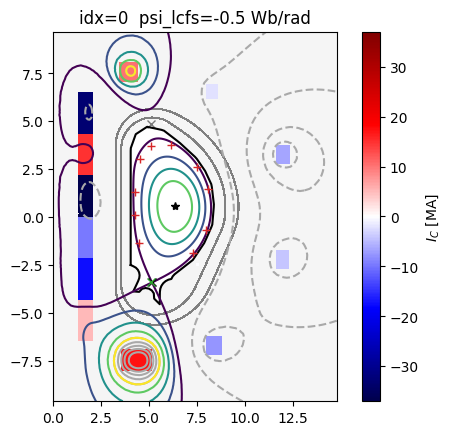

Saving gEQDSK: /Users/fsheehan/github/fs2819-OpenFUSIONToolkit/src/examples/TokaMaker/AdvancedWorkflows/Pulse_Design/ITER_TokaMakerTORAX/ITER_rampdown_flattop.eqdsk
 Using COCOS=2...
Equilibrium Statistics:
  Topology                =   Diverted
  Toroidal Current [A]    =    1.5000E+07
  Current Centroid [m]    =    6.197  0.554
  Magnetic Axis [m]       =    6.368  0.550
  Elongation              =    1.852 (U:  1.750, L:  1.953)
  Triangularity           =    0.438 (U:  0.357, L:  0.520)
  Plasma Volume [m^3]     =   861.766
  q_0, q_95               =    0.931  3.023
  Plasma Pressure [Pa]    =   Axis:  6.0037E+05, Peak:  6.0037E+05
  Stored Energy [J]       =    2.5225E+08
  <Beta_pol> [%]          =   46.9600
  <Beta_tor> [%]          =    1.7653
  <Beta_n>   [%]          =    1.2597
  Diamagnetic flux [Wb]   =    1.3097E+00
  Toroidal flux [Wb]      =    1.2833E+02
  l_i                     =    1.1013
15000000.0
Starting non-linear GS solver
     1  7.3944E+00  1.3007E-01  3.99

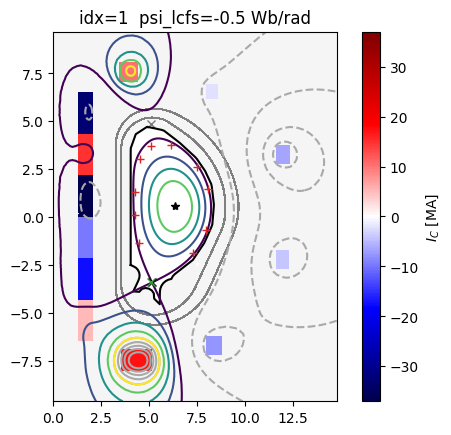

Saving gEQDSK: /Users/fsheehan/github/fs2819-OpenFUSIONToolkit/src/examples/TokaMaker/AdvancedWorkflows/Pulse_Design/ITER_TokaMakerTORAX/ITER_rampdown_flattop_end.eqdsk
 Using COCOS=2...
Equilibrium Statistics:
  Topology                =   Diverted
  Toroidal Current [A]    =    1.5000E+07
  Current Centroid [m]    =    6.197  0.554
  Magnetic Axis [m]       =    6.368  0.550
  Elongation              =    1.852 (U:  1.750, L:  1.953)
  Triangularity           =    0.439 (U:  0.358, L:  0.520)
  Plasma Volume [m^3]     =   861.766
  q_0, q_95               =    0.931  3.023
  Plasma Pressure [Pa]    =   Axis:  6.0037E+05, Peak:  6.0037E+05
  Stored Energy [J]       =    2.5225E+08
  <Beta_pol> [%]          =   46.9613
  <Beta_tor> [%]          =    1.7653
  <Beta_n>   [%]          =    1.2597
  Diamagnetic flux [Wb]   =    1.3097E+00
  Toroidal flux [Wb]      =    1.2833E+02
  l_i                     =    1.1013
7000000.0
Starting non-linear GS solver
     1  2.9918E-01  8.3619E-02  1

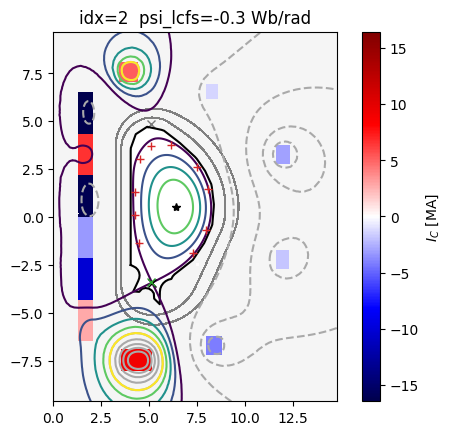

Saving gEQDSK: /Users/fsheehan/github/fs2819-OpenFUSIONToolkit/src/examples/TokaMaker/AdvancedWorkflows/Pulse_Design/ITER_TokaMakerTORAX/ITER_rampdown_ramp_diverted_42.eqdsk
 Using COCOS=2...
Equilibrium Statistics:
  Topology                =   Diverted
  Toroidal Current [A]    =    7.0000E+06
  Current Centroid [m]    =    6.225  0.550
  Magnetic Axis [m]       =    6.408  0.545
  Elongation              =    1.850 (U:  1.747, L:  1.952)
  Triangularity           =    0.442 (U:  0.355, L:  0.528)
  Plasma Volume [m^3]     =   866.112
  q_0, q_95               =    2.257  6.604
  Plasma Pressure [Pa]    =   Axis:  1.8011E+05, Peak:  1.8011E+05
  Stored Energy [J]       =    8.0142E+07
  <Beta_pol> [%]          =   69.1115
  <Beta_tor> [%]          =    0.5572
  <Beta_n>   [%]          =    0.8566
  Diamagnetic flux [Wb]   =    1.8400E-01
  Toroidal flux [Wb]      =    1.2796E+02
  l_i                     =    0.9826
5000000.0
Starting non-linear GS solver
     1 -1.6861E+00  7.7399E-

    20  2.8117E+00  4.9038E-02  2.2340E-05  6.2957E+00  5.0082E-01  2.2251E-03
    21  2.8122E+00  4.9036E-02  1.4811E-05  6.2957E+00  5.0082E-01  2.2252E-03
    22  2.8126E+00  4.9034E-02  9.8198E-06  6.2957E+00  5.0082E-01  2.2252E-03
    23  2.8128E+00  4.9033E-02  6.5103E-06  6.2956E+00  5.0082E-01  2.2252E-03
    24  2.8130E+00  4.9032E-02  4.3161E-06  6.2956E+00  5.0082E-01  2.2252E-03
    25  2.8131E+00  4.9032E-02  2.8614E-06  6.2956E+00  5.0082E-01  2.2252E-03
    26  2.8131E+00  4.9031E-02  1.8969E-06  6.2956E+00  5.0082E-01  2.2252E-03
    27  2.8132E+00  4.9031E-02  1.2575E-06  6.2956E+00  5.0082E-01  2.2252E-03
    28  2.8132E+00  4.9031E-02  8.3366E-07  6.2956E+00  5.0082E-01  2.2252E-03
 Timing:  0.24583099999290425     
   Source:     6.0297000003629364E-002
   Solve:      5.2593999993405305E-002
   Boundary:   1.0637999992468394E-002
   Other:     0.12230200000340119     
idx=3: target psi_lcfs = 0.00 Wb/rad
      solved psi_lcfs = 0.21 Wb/rad  (1.3 Wb)


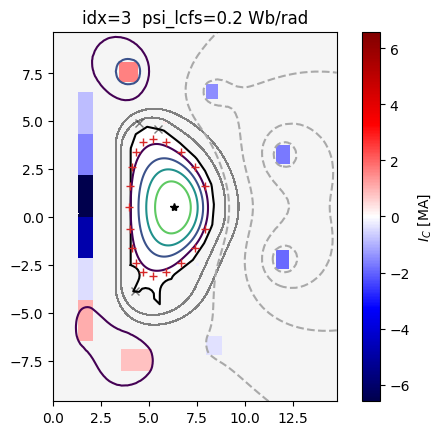

Saving gEQDSK: /Users/fsheehan/github/fs2819-OpenFUSIONToolkit/src/examples/TokaMaker/AdvancedWorkflows/Pulse_Design/ITER_TokaMakerTORAX/ITER_rampdown_ramp_limited_45.eqdsk
 Using COCOS=2...
Equilibrium Statistics:
  Topology                =   Limited
  Toroidal Current [A]    =    5.0000E+06
  Current Centroid [m]    =    6.104  0.501
  Magnetic Axis [m]       =    6.296  0.501
  Elongation              =    1.640 (U:  1.641, L:  1.639)
  Triangularity           =    0.332 (U:  0.336, L:  0.327)
  Plasma Volume [m^3]     =   769.004
  q_0, q_95               =    3.346  8.400
  Plasma Pressure [Pa]    =   Axis:  1.2007E+05, Peak:  1.2007E+05
  Stored Energy [J]       =    4.9968E+07
  <Beta_pol> [%]          =   80.2274
  <Beta_tor> [%]          =    0.3731
  <Beta_n>   [%]          =    0.8138
  Diamagnetic flux [Wb]   =    5.8055E-02
  Toroidal flux [Wb]      =    1.1887E+02
  l_i                     =    0.8558
2500000.0
Starting non-linear GS solver
     1 -1.6471E+00  6.9602E-02

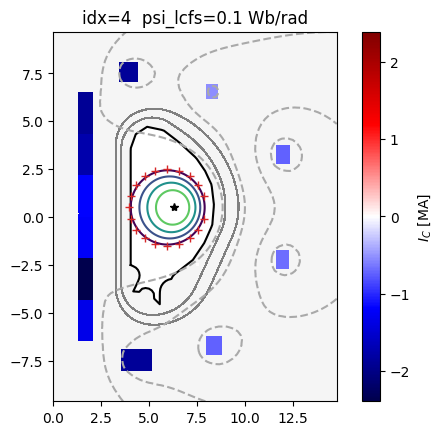

Saving gEQDSK: /Users/fsheehan/github/fs2819-OpenFUSIONToolkit/src/examples/TokaMaker/AdvancedWorkflows/Pulse_Design/ITER_TokaMakerTORAX/ITER_rampdown_ramp_limited_round.eqdsk
 Using COCOS=2...
Equilibrium Statistics:
  Topology                =   Limited
  Toroidal Current [A]    =    2.5000E+06
  Current Centroid [m]    =    6.148  0.500
  Magnetic Axis [m]       =    6.292  0.500
  Elongation              =    1.004 (U:  1.004, L:  1.004)
  Triangularity           =   -0.000 (U: -0.000, L:  0.000)
  Plasma Volume [m^3]     =   441.277
  q_0, q_95               =    3.908  7.558
  Plasma Pressure [Pa]    =   Axis:  6.0038E+04, Peak:  6.0038E+04
  Stored Energy [J]       =    1.5126E+07
  <Beta_pol> [%]          =   85.9512
  <Beta_tor> [%]          =    0.1912
  <Beta_n>   [%]          =    0.8097
  Diamagnetic flux [Wb]   =    1.1468E-02
  Toroidal flux [Wb]      =    6.6193E+01
  l_i                     =    0.8054
500000.0
Starting non-linear GS solver
     1  3.4484E+00  2.5948E-

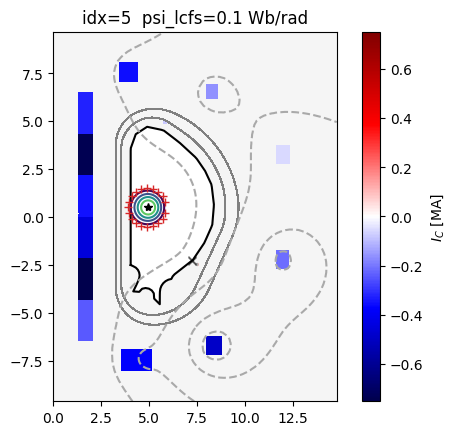

Saving gEQDSK: /Users/fsheehan/github/fs2819-OpenFUSIONToolkit/src/examples/TokaMaker/AdvancedWorkflows/Pulse_Design/ITER_TokaMakerTORAX/ITER_rampdown_pulse_end.eqdsk
 Using COCOS=2...
Equilibrium Statistics:
  Topology                =   Limited
  Toroidal Current [A]    =    5.0000E+05
  Current Centroid [m]    =    4.932  0.500
  Magnetic Axis [m]       =    4.961  0.500
  Elongation              =    1.003 (U:  1.003, L:  1.003)
  Triangularity           =   -0.003 (U: -0.002, L: -0.005)
  Plasma Volume [m^3]     =   74.551
  q_0, q_95               =    4.022  9.877
  Plasma Pressure [Pa]    =   Axis:  3.2000E+03, Peak:  3.2000E+03
  Stored Energy [J]       =    1.1970E+05
  <Beta_pol> [%]          =   20.6562
  <Beta_tor> [%]          =    0.0061
  <Beta_n>   [%]          =    0.0707
  Diamagnetic flux [Wb]   =    1.8664E-03
  Toroidal flux [Wb]      =    1.6179E+01
  l_i                     =    1.1425


In [6]:
# Solve and save anchor equilibria (see markdown): flattop pair, diverted mid, limited first, limited round, pulse end
psi_lcfs_results = []
eqdsk_paths = []

for idx in range(len(a)):
    psi_lcfs_target = target_psi_lcfs[idx]

    if diverted[idx]:
        R = R0
        mygs.set_saddle_constraints(x_points)
        mygs.set_isoflux_constraints(diverted_isoflux_pts)
        psi_lcfs_weight = 10
        targets = np.full(diverted_isoflux_pts.shape[0], psi_lcfs_target)
        weights = np.full(diverted_isoflux_pts.shape[0], psi_lcfs_weight)
        mygs.set_psi_constraints(diverted_isoflux_pts, targets, weights=weights)
    else:
        mygs.set_saddle_constraints(None)
        R = R_init_psi[idx]
        isoflux_pts = create_isoflux(20, R, Z0, a[idx], kappa[idx], delta[idx])
        mygs.set_isoflux_constraints(isoflux_pts)
        psi_lcfs_weight = 10
        targets = np.full(isoflux_pts.shape[0], psi_lcfs_target)
        weights = np.full(isoflux_pts.shape[0], psi_lcfs_weight)
        mygs.set_psi_constraints(isoflux_pts, targets, weights=weights)

    build_min_norm_coil_reg(mygs)
    print(Ip_targets[idx])
    mygs.set_targets(Ip=Ip_targets[idx], pax=pax_targets[idx])
    mygs.init_psi(R, Z0, a[idx], kappa[idx], delta[idx])
    _ = mygs.solve()

    psi_lcfs = mygs.psi_bounds[0]
    psi_lcfs_results.append(psi_lcfs)
    print(f'idx={idx}: target psi_lcfs = {psi_lcfs_target:.2f} Wb/rad')
    print(f'      solved psi_lcfs = {psi_lcfs:.2f} Wb/rad  ({psi_lcfs*2*np.pi:.1f} Wb)')

    fig, ax = plt.subplots(1, 1)
    mygs.plot_machine(fig, ax, coil_colormap='seismic', coil_scale=1.E-6,
                      coil_clabel=r'$I_C$ [MA]', coil_symmap=True)
    mygs.plot_psi(fig, ax, plasma_nlevels=5, vacuum_nlevels=5)
    mygs.plot_constraints(fig, ax)
    # ax.plot(R_MAJOR_LIM, 0, 'k+', ms=10)
    ax.set_title(f'idx={idx}  psi_lcfs={psi_lcfs:.1f} Wb/rad')
    plt.show()

    eqdsk_labels = [
        'flattop', 'flattop_end',
        'ramp_diverted_42', 'ramp_limited_45',
        'ramp_limited_round', 'pulse_end',
    ]  # idx matches eqtimes chronological order
    eqdsk_name = os.path.join(cwd, f'ITER_rampdown_{eqdsk_labels[idx]}.eqdsk')
    mygs.save_eqdsk(eqdsk_name, cocos=2, nr=500, nz=500)
    eqdsk_paths.append(eqdsk_name)
    mygs.print_info()
    # print(mygs.get_stats())


In [ ]:
eqtimes = [
    T_FLAT_START, T_RAMP_START,
    T_DIV_MID, T_LIMIT_FIRST, T_LIMIT_ROUND,
    T_FINAL,
]
eqdsk_list = list(eqdsk_paths)

tt = TokTox(
    t_init=T_FLAT_START,
    t_final=T_FINAL,
    tx_dt=1.0,
    eqtimes=eqtimes,
    g_eqdsk_arr=eqdsk_list,
    last_surface_factor=0.9999,
    tm_times=np.linspace(T_FLAT_START, T_FINAL, 30),
    oft_env=myOFT,
)

In [ ]:
# tt.set_tx_grid(grid_type='face_centers', grid=np.unique(np.concatenate([np.linspace(0.0, 0.7, 25), np.linspace(0.7, 1.0, 50)])))
tt.set_tx_grid(grid_type='n_rho', grid=101)

In [9]:
# Heating: hold full-power NBI+ECRH through short flattop, then taper like full-pulse notebook
ecrh_powers = {
    T_FLAT_START: 20.0e6,
    T_RAMP_START: 20.0e6,
    T_DIV_MID: 0.0e6,
    55: 0,
    T_LIMIT_FIRST: 0.0,
    T_FINAL:  0.0,
}
generic_powers = {
    T_FLAT_START: 33.0e6,
    T_RAMP_START: 33.0e6,
    T_DIV_MID: 0.0e6,
    55: 0,
    T_LIMIT_FIRST: 0.0,
    T_FINAL:  0.0,
}

tt.set_heating(generic_heat=generic_powers, generic_heat_loc=0.25, nbi_current=True,
               ecrh=ecrh_powers, ecrh_loc=0.35)
tt.set_sources(fusion=True, ei_exchange=True)
tt.set_gas_puff(S_total={0:1e21, T_RAMP_START:1e21, T_FINAL:1e20}, decay_length=0.15)
tt.set_pellet(pellet_deposition_location=0.8, pellet_width=0.1,
              S_total={T_FLAT_START: 5e21, T_RAMP_START: 5e21, T_RAMP_START + 10.0: 0.0})

In [10]:
n_e_x = np.array([0.        , 0.001001  , 0.002002  , 0.003003  , 0.004004  ,
       0.00500501, 0.00600601, 0.00700701, 0.00800801, 0.00900901,
       0.01001001, 0.01101101, 0.01201201, 0.01301301, 0.01401401,
       0.01501502, 0.01601602, 0.01701702, 0.01801802, 0.01901902,
       0.02002002, 0.02102102, 0.02202202, 0.02302302, 0.02402402,
       0.02502503, 0.02602603, 0.02702703, 0.02802803, 0.02902903,
       0.03003003, 0.03103103, 0.03203203, 0.03303303, 0.03403403,
       0.03503504, 0.03603604, 0.03703704, 0.03803804, 0.03903904,
       0.04004004, 0.04104104, 0.04204204, 0.04304304, 0.04404404,
       0.04504505, 0.04604605, 0.04704705, 0.04804805, 0.04904905,
       0.05005005, 0.05105105, 0.05205205, 0.05305305, 0.05405405,
       0.05505506, 0.05605606, 0.05705706, 0.05805806, 0.05905906,
       0.06006006, 0.06106106, 0.06206206, 0.06306306, 0.06406406,
       0.06506507, 0.06606607, 0.06706707, 0.06806807, 0.06906907,
       0.07007007, 0.07107107, 0.07207207, 0.07307307, 0.07407407,
       0.07507508, 0.07607608, 0.07707708, 0.07807808, 0.07907908,
       0.08008008, 0.08108108, 0.08208208, 0.08308308, 0.08408408,
       0.08508509, 0.08608609, 0.08708709, 0.08808809, 0.08908909,
       0.09009009, 0.09109109, 0.09209209, 0.09309309, 0.09409409,
       0.0950951 , 0.0960961 , 0.0970971 , 0.0980981 , 0.0990991 ,
       0.1001001 , 0.1011011 , 0.1021021 , 0.1031031 , 0.1041041 ,
       0.10510511, 0.10610611, 0.10710711, 0.10810811, 0.10910911,
       0.11011011, 0.11111111, 0.11211211, 0.11311311, 0.11411411,
       0.11511512, 0.11611612, 0.11711712, 0.11811812, 0.11911912,
       0.12012012, 0.12112112, 0.12212212, 0.12312312, 0.12412412,
       0.12512513, 0.12612613, 0.12712713, 0.12812813, 0.12912913,
       0.13013013, 0.13113113, 0.13213213, 0.13313313, 0.13413413,
       0.13513514, 0.13613614, 0.13713714, 0.13813814, 0.13913914,
       0.14014014, 0.14114114, 0.14214214, 0.14314314, 0.14414414,
       0.14514515, 0.14614615, 0.14714715, 0.14814815, 0.14914915,
       0.15015015, 0.15115115, 0.15215215, 0.15315315, 0.15415415,
       0.15515516, 0.15615616, 0.15715716, 0.15815816, 0.15915916,
       0.16016016, 0.16116116, 0.16216216, 0.16316316, 0.16416416,
       0.16516517, 0.16616617, 0.16716717, 0.16816817, 0.16916917,
       0.17017017, 0.17117117, 0.17217217, 0.17317317, 0.17417417,
       0.17517518, 0.17617618, 0.17717718, 0.17817818, 0.17917918,
       0.18018018, 0.18118118, 0.18218218, 0.18318318, 0.18418418,
       0.18518519, 0.18618619, 0.18718719, 0.18818819, 0.18918919,
       0.19019019, 0.19119119, 0.19219219, 0.19319319, 0.19419419,
       0.1951952 , 0.1961962 , 0.1971972 , 0.1981982 , 0.1991992 ,
       0.2002002 , 0.2012012 , 0.2022022 , 0.2032032 , 0.2042042 ,
       0.20520521, 0.20620621, 0.20720721, 0.20820821, 0.20920921,
       0.21021021, 0.21121121, 0.21221221, 0.21321321, 0.21421421,
       0.21521522, 0.21621622, 0.21721722, 0.21821822, 0.21921922,
       0.22022022, 0.22122122, 0.22222222, 0.22322322, 0.22422422,
       0.22522523, 0.22622623, 0.22722723, 0.22822823, 0.22922923,
       0.23023023, 0.23123123, 0.23223223, 0.23323323, 0.23423423,
       0.23523524, 0.23623624, 0.23723724, 0.23823824, 0.23923924,
       0.24024024, 0.24124124, 0.24224224, 0.24324324, 0.24424424,
       0.24524525, 0.24624625, 0.24724725, 0.24824825, 0.24924925,
       0.25025025, 0.25125125, 0.25225225, 0.25325325, 0.25425425,
       0.25525526, 0.25625626, 0.25725726, 0.25825826, 0.25925926,
       0.26026026, 0.26126126, 0.26226226, 0.26326326, 0.26426426,
       0.26526527, 0.26626627, 0.26726727, 0.26826827, 0.26926927,
       0.27027027, 0.27127127, 0.27227227, 0.27327327, 0.27427427,
       0.27527528, 0.27627628, 0.27727728, 0.27827828, 0.27927928,
       0.28028028, 0.28128128, 0.28228228, 0.28328328, 0.28428428,
       0.28528529, 0.28628629, 0.28728729, 0.28828829, 0.28928929,
       0.29029029, 0.29129129, 0.29229229, 0.29329329, 0.29429429,
       0.2952953 , 0.2962963 , 0.2972973 , 0.2982983 , 0.2992993 ,
       0.3003003 , 0.3013013 , 0.3023023 , 0.3033033 , 0.3043043 ,
       0.30530531, 0.30630631, 0.30730731, 0.30830831, 0.30930931,
       0.31031031, 0.31131131, 0.31231231, 0.31331331, 0.31431431,
       0.31531532, 0.31631632, 0.31731732, 0.31831832, 0.31931932,
       0.32032032, 0.32132132, 0.32232232, 0.32332332, 0.32432432,
       0.32532533, 0.32632633, 0.32732733, 0.32832833, 0.32932933,
       0.33033033, 0.33133133, 0.33233233, 0.33333333, 0.33433433,
       0.33533534, 0.33633634, 0.33733734, 0.33833834, 0.33933934,
       0.34034034, 0.34134134, 0.34234234, 0.34334334, 0.34434434,
       0.34534535, 0.34634635, 0.34734735, 0.34834835, 0.34934935,
       0.35035035, 0.35135135, 0.35235235, 0.35335335, 0.35435435,
       0.35535536, 0.35635636, 0.35735736, 0.35835836, 0.35935936,
       0.36036036, 0.36136136, 0.36236236, 0.36336336, 0.36436436,
       0.36536537, 0.36636637, 0.36736737, 0.36836837, 0.36936937,
       0.37037037, 0.37137137, 0.37237237, 0.37337337, 0.37437437,
       0.37537538, 0.37637638, 0.37737738, 0.37837838, 0.37937938,
       0.38038038, 0.38138138, 0.38238238, 0.38338338, 0.38438438,
       0.38538539, 0.38638639, 0.38738739, 0.38838839, 0.38938939,
       0.39039039, 0.39139139, 0.39239239, 0.39339339, 0.39439439,
       0.3953954 , 0.3963964 , 0.3973974 , 0.3983984 , 0.3993994 ,
       0.4004004 , 0.4014014 , 0.4024024 , 0.4034034 , 0.4044044 ,
       0.40540541, 0.40640641, 0.40740741, 0.40840841, 0.40940941,
       0.41041041, 0.41141141, 0.41241241, 0.41341341, 0.41441441,
       0.41541542, 0.41641642, 0.41741742, 0.41841842, 0.41941942,
       0.42042042, 0.42142142, 0.42242242, 0.42342342, 0.42442442,
       0.42542543, 0.42642643, 0.42742743, 0.42842843, 0.42942943,
       0.43043043, 0.43143143, 0.43243243, 0.43343343, 0.43443443,
       0.43543544, 0.43643644, 0.43743744, 0.43843844, 0.43943944,
       0.44044044, 0.44144144, 0.44244244, 0.44344344, 0.44444444,
       0.44544545, 0.44644645, 0.44744745, 0.44844845, 0.44944945,
       0.45045045, 0.45145145, 0.45245245, 0.45345345, 0.45445445,
       0.45545546, 0.45645646, 0.45745746, 0.45845846, 0.45945946,
       0.46046046, 0.46146146, 0.46246246, 0.46346346, 0.46446446,
       0.46546547, 0.46646647, 0.46746747, 0.46846847, 0.46946947,
       0.47047047, 0.47147147, 0.47247247, 0.47347347, 0.47447447,
       0.47547548, 0.47647648, 0.47747748, 0.47847848, 0.47947948,
       0.48048048, 0.48148148, 0.48248248, 0.48348348, 0.48448448,
       0.48548549, 0.48648649, 0.48748749, 0.48848849, 0.48948949,
       0.49049049, 0.49149149, 0.49249249, 0.49349349, 0.49449449,
       0.4954955 , 0.4964965 , 0.4974975 , 0.4984985 , 0.4994995 ,
       0.5005005 , 0.5015015 , 0.5025025 , 0.5035035 , 0.5045045 ,
       0.50550551, 0.50650651, 0.50750751, 0.50850851, 0.50950951,
       0.51051051, 0.51151151, 0.51251251, 0.51351351, 0.51451451,
       0.51551552, 0.51651652, 0.51751752, 0.51851852, 0.51951952,
       0.52052052, 0.52152152, 0.52252252, 0.52352352, 0.52452452,
       0.52552553, 0.52652653, 0.52752753, 0.52852853, 0.52952953,
       0.53053053, 0.53153153, 0.53253253, 0.53353353, 0.53453453,
       0.53553554, 0.53653654, 0.53753754, 0.53853854, 0.53953954,
       0.54054054, 0.54154154, 0.54254254, 0.54354354, 0.54454454,
       0.54554555, 0.54654655, 0.54754755, 0.54854855, 0.54954955,
       0.55055055, 0.55155155, 0.55255255, 0.55355355, 0.55455455,
       0.55555556, 0.55655656, 0.55755756, 0.55855856, 0.55955956,
       0.56056056, 0.56156156, 0.56256256, 0.56356356, 0.56456456,
       0.56556557, 0.56656657, 0.56756757, 0.56856857, 0.56956957,
       0.57057057, 0.57157157, 0.57257257, 0.57357357, 0.57457457,
       0.57557558, 0.57657658, 0.57757758, 0.57857858, 0.57957958,
       0.58058058, 0.58158158, 0.58258258, 0.58358358, 0.58458458,
       0.58558559, 0.58658659, 0.58758759, 0.58858859, 0.58958959,
       0.59059059, 0.59159159, 0.59259259, 0.59359359, 0.59459459,
       0.5955956 , 0.5965966 , 0.5975976 , 0.5985986 , 0.5995996 ,
       0.6006006 , 0.6016016 , 0.6026026 , 0.6036036 , 0.6046046 ,
       0.60560561, 0.60660661, 0.60760761, 0.60860861, 0.60960961,
       0.61061061, 0.61161161, 0.61261261, 0.61361361, 0.61461461,
       0.61561562, 0.61661662, 0.61761762, 0.61861862, 0.61961962,
       0.62062062, 0.62162162, 0.62262262, 0.62362362, 0.62462462,
       0.62562563, 0.62662663, 0.62762763, 0.62862863, 0.62962963,
       0.63063063, 0.63163163, 0.63263263, 0.63363363, 0.63463463,
       0.63563564, 0.63663664, 0.63763764, 0.63863864, 0.63963964,
       0.64064064, 0.64164164, 0.64264264, 0.64364364, 0.64464464,
       0.64564565, 0.64664665, 0.64764765, 0.64864865, 0.64964965,
       0.65065065, 0.65165165, 0.65265265, 0.65365365, 0.65465465,
       0.65565566, 0.65665666, 0.65765766, 0.65865866, 0.65965966,
       0.66066066, 0.66166166, 0.66266266, 0.66366366, 0.66466466,
       0.66566567, 0.66666667, 0.66766767, 0.66866867, 0.66966967,
       0.67067067, 0.67167167, 0.67267267, 0.67367367, 0.67467467,
       0.67567568, 0.67667668, 0.67767768, 0.67867868, 0.67967968,
       0.68068068, 0.68168168, 0.68268268, 0.68368368, 0.68468468,
       0.68568569, 0.68668669, 0.68768769, 0.68868869, 0.68968969,
       0.69069069, 0.69169169, 0.69269269, 0.69369369, 0.69469469,
       0.6956957 , 0.6966967 , 0.6976977 , 0.6986987 , 0.6996997 ,
       0.7007007 , 0.7017017 , 0.7027027 , 0.7037037 , 0.7047047 ,
       0.70570571, 0.70670671, 0.70770771, 0.70870871, 0.70970971,
       0.71071071, 0.71171171, 0.71271271, 0.71371371, 0.71471471,
       0.71571572, 0.71671672, 0.71771772, 0.71871872, 0.71971972,
       0.72072072, 0.72172172, 0.72272272, 0.72372372, 0.72472472,
       0.72572573, 0.72672673, 0.72772773, 0.72872873, 0.72972973,
       0.73073073, 0.73173173, 0.73273273, 0.73373373, 0.73473473,
       0.73573574, 0.73673674, 0.73773774, 0.73873874, 0.73973974,
       0.74074074, 0.74174174, 0.74274274, 0.74374374, 0.74474474,
       0.74574575, 0.74674675, 0.74774775, 0.74874875, 0.74974975,
       0.75075075, 0.75175175, 0.75275275, 0.75375375, 0.75475475,
       0.75575576, 0.75675676, 0.75775776, 0.75875876, 0.75975976,
       0.76076076, 0.76176176, 0.76276276, 0.76376376, 0.76476476,
       0.76576577, 0.76676677, 0.76776777, 0.76876877, 0.76976977,
       0.77077077, 0.77177177, 0.77277277, 0.77377377, 0.77477477,
       0.77577578, 0.77677678, 0.77777778, 0.77877878, 0.77977978,
       0.78078078, 0.78178178, 0.78278278, 0.78378378, 0.78478478,
       0.78578579, 0.78678679, 0.78778779, 0.78878879, 0.78978979,
       0.79079079, 0.79179179, 0.79279279, 0.79379379, 0.79479479,
       0.7957958 , 0.7967968 , 0.7977978 , 0.7987988 , 0.7997998 ,
       0.8008008 , 0.8018018 , 0.8028028 , 0.8038038 , 0.8048048 ,
       0.80580581, 0.80680681, 0.80780781, 0.80880881, 0.80980981,
       0.81081081, 0.81181181, 0.81281281, 0.81381381, 0.81481481,
       0.81581582, 0.81681682, 0.81781782, 0.81881882, 0.81981982,
       0.82082082, 0.82182182, 0.82282282, 0.82382382, 0.82482482,
       0.82582583, 0.82682683, 0.82782783, 0.82882883, 0.82982983,
       0.83083083, 0.83183183, 0.83283283, 0.83383383, 0.83483483,
       0.83583584, 0.83683684, 0.83783784, 0.83883884, 0.83983984,
       0.84084084, 0.84184184, 0.84284284, 0.84384384, 0.84484484,
       0.84584585, 0.84684685, 0.84784785, 0.84884885, 0.84984985,
       0.85085085, 0.85185185, 0.85285285, 0.85385385, 0.85485485,
       0.85585586, 0.85685686, 0.85785786, 0.85885886, 0.85985986,
       0.86086086, 0.86186186, 0.86286286, 0.86386386, 0.86486486,
       0.86586587, 0.86686687, 0.86786787, 0.86886887, 0.86986987,
       0.87087087, 0.87187187, 0.87287287, 0.87387387, 0.87487487,
       0.87587588, 0.87687688, 0.87787788, 0.87887888, 0.87987988,
       0.88088088, 0.88188188, 0.88288288, 0.88388388, 0.88488488,
       0.88588589, 0.88688689, 0.88788789, 0.88888889, 0.88988989,
       0.89089089, 0.89189189, 0.89289289, 0.89389389, 0.89489489,
       0.8958959 , 0.8968969 , 0.8978979 , 0.8988989 , 0.8998999 ,
       0.9009009 , 0.9019019 , 0.9029029 , 0.9039039 , 0.9049049 ,
       0.90590591, 0.90690691, 0.90790791, 0.90890891, 0.90990991,
       0.91091091, 0.91191191, 0.91291291, 0.91391391, 0.91491491,
       0.91591592, 0.91691692, 0.91791792, 0.91891892, 0.91991992,
       0.92092092, 0.92192192, 0.92292292, 0.92392392, 0.92492492,
       0.92592593, 0.92692693, 0.92792793, 0.92892893, 0.92992993,
       0.93093093, 0.93193193, 0.93293293, 0.93393393, 0.93493493,
       0.93593594, 0.93693694, 0.93793794, 0.93893894, 0.93993994,
       0.94094094, 0.94194194, 0.94294294, 0.94394394, 0.94494494,
       0.94594595, 0.94694695, 0.94794795, 0.94894895, 0.94994995,
       0.95095095, 0.95195195, 0.95295295, 0.95395395, 0.95495495,
       0.95595596, 0.95695696, 0.95795796, 0.95895896, 0.95995996,
       0.96096096, 0.96196196, 0.96296296, 0.96396396, 0.96496496,
       0.96596597, 0.96696697, 0.96796797, 0.96896897, 0.96996997,
       0.97097097, 0.97197197, 0.97297297, 0.97397397, 0.97497497,
       0.97597598, 0.97697698, 0.97797798, 0.97897898, 0.97997998,
       0.98098098, 0.98198198, 0.98298298, 0.98398398, 0.98498498,
       0.98598599, 0.98698699, 0.98798799, 0.98898899, 0.98998999,
       0.99099099, 0.99199199, 0.99299299, 0.99399399, 0.99499499,
       0.995996  , 0.996997  , 0.997998  , 0.998999  , 1.        ])
n_e_y = np.array([1.48335471e+20, 1.48248407e+20, 1.48158246e+20, 1.48066105e+20,
       1.47972800e+20, 1.47878709e+20, 1.47776643e+20, 1.47673559e+20,
       1.47569225e+20, 1.47464766e+20, 1.47359574e+20, 1.47253941e+20,
       1.47148277e+20, 1.47041652e+20, 1.46935028e+20, 1.46828297e+20,
       1.46720850e+20, 1.46613404e+20, 1.46505957e+20, 1.46396690e+20,
       1.46287261e+20, 1.46177832e+20, 1.46072521e+20, 1.45973470e+20,
       1.45874418e+20, 1.45775367e+20, 1.45680584e+20, 1.45589156e+20,
       1.45497728e+20, 1.45406300e+20, 1.45317154e+20, 1.45231318e+20,
       1.45145482e+20, 1.45059646e+20, 1.44973810e+20, 1.44892000e+20,
       1.44810446e+20, 1.44728891e+20, 1.44647336e+20, 1.44566246e+20,
       1.44487677e+20, 1.44409108e+20, 1.44330540e+20, 1.44251971e+20,
       1.44173671e+20, 1.44099727e+20, 1.44025783e+20, 1.43951840e+20,
       1.43877896e+20, 1.43803953e+20, 1.43732377e+20, 1.43662051e+20,
       1.43591725e+20, 1.43521399e+20, 1.43451072e+20, 1.43380746e+20,
       1.43313128e+20, 1.43245662e+20, 1.43178196e+20, 1.43110730e+20,
       1.43043265e+20, 1.42975799e+20, 1.42910929e+20, 1.42846235e+20,
       1.42781542e+20, 1.42716848e+20, 1.42652155e+20, 1.42587461e+20,
       1.42524474e+20, 1.42462544e+20, 1.42400614e+20, 1.42338684e+20,
       1.42276755e+20, 1.42214825e+20, 1.42152895e+20, 1.42093207e+20,
       1.42033538e+20, 1.41973869e+20, 1.41914200e+20, 1.41854531e+20,
       1.41794862e+20, 1.41735293e+20, 1.41677204e+20, 1.41619115e+20,
       1.41561026e+20, 1.41502937e+20, 1.41444848e+20, 1.41386758e+20,
       1.41328669e+20, 1.41272381e+20, 1.41216501e+20, 1.41160620e+20,
       1.41104740e+20, 1.41048860e+20, 1.40992979e+20, 1.40937099e+20,
       1.40881721e+20, 1.40827882e+20, 1.40774043e+20, 1.40720204e+20,
       1.40666365e+20, 1.40612526e+20, 1.40558687e+20, 1.40504848e+20,
       1.40451721e+20, 1.40399903e+20, 1.40348086e+20, 1.40296268e+20,
       1.40244450e+20, 1.40192632e+20, 1.40140814e+20, 1.40088997e+20,
       1.40037341e+20, 1.39986759e+20, 1.39936176e+20, 1.39885594e+20,
       1.39835012e+20, 1.39784429e+20, 1.39733847e+20, 1.39683264e+20,
       1.39632682e+20, 1.39583115e+20, 1.39534286e+20, 1.39485457e+20,
       1.39436628e+20, 1.39387799e+20, 1.39338969e+20, 1.39290140e+20,
       1.39241311e+20, 1.39192482e+20, 1.39144793e+20, 1.39097573e+20,
       1.39050353e+20, 1.39003133e+20, 1.38955914e+20, 1.38908694e+20,
       1.38861474e+20, 1.38814254e+20, 1.38767034e+20, 1.38720569e+20,
       1.38674811e+20, 1.38629054e+20, 1.38583296e+20, 1.38537539e+20,
       1.38491781e+20, 1.38446024e+20, 1.38400266e+20, 1.38354508e+20,
       1.38308692e+20, 1.38260310e+20, 1.38211928e+20, 1.38163547e+20,
       1.38115165e+20, 1.38066783e+20, 1.38018402e+20, 1.37970020e+20,
       1.37921638e+20, 1.37873257e+20, 1.37824804e+20, 1.37776127e+20,
       1.37727450e+20, 1.37678773e+20, 1.37630095e+20, 1.37581418e+20,
       1.37532741e+20, 1.37484064e+20, 1.37435387e+20, 1.37386710e+20,
       1.37337436e+20, 1.37285235e+20, 1.37233035e+20, 1.37180834e+20,
       1.37128633e+20, 1.37076432e+20, 1.37024231e+20, 1.36972030e+20,
       1.36919830e+20, 1.36867629e+20, 1.36815428e+20, 1.36762786e+20,
       1.36710041e+20, 1.36657296e+20, 1.36604551e+20, 1.36551806e+20,
       1.36499061e+20, 1.36446316e+20, 1.36393571e+20, 1.36340826e+20,
       1.36288081e+20, 1.36234794e+20, 1.36177430e+20, 1.36120067e+20,
       1.36062703e+20, 1.36005339e+20, 1.35947975e+20, 1.35890612e+20,
       1.35833248e+20, 1.35775884e+20, 1.35718520e+20, 1.35661157e+20,
       1.35603701e+20, 1.35545216e+20, 1.35486731e+20, 1.35428246e+20,
       1.35369761e+20, 1.35311276e+20, 1.35252791e+20, 1.35194307e+20,
       1.35135822e+20, 1.35077337e+20, 1.35018852e+20, 1.34960367e+20,
       1.34896836e+20, 1.34831645e+20, 1.34766454e+20, 1.34701263e+20,
       1.34636073e+20, 1.34570882e+20, 1.34505691e+20, 1.34440501e+20,
       1.34375310e+20, 1.34310119e+20, 1.34244929e+20, 1.34179958e+20,
       1.34116348e+20, 1.34052739e+20, 1.33989129e+20, 1.33925519e+20,
       1.33861909e+20, 1.33798300e+20, 1.33734690e+20, 1.33671080e+20,
       1.33607470e+20, 1.33543860e+20, 1.33480251e+20, 1.33416418e+20,
       1.33352009e+20, 1.33287599e+20, 1.33223190e+20, 1.33158781e+20,
       1.33094372e+20, 1.33029962e+20, 1.32965553e+20, 1.32901144e+20,
       1.32836734e+20, 1.32772325e+20, 1.32707916e+20, 1.32643757e+20,
       1.32580746e+20, 1.32517736e+20, 1.32454726e+20, 1.32391715e+20,
       1.32328705e+20, 1.32265695e+20, 1.32202684e+20, 1.32139674e+20,
       1.32076664e+20, 1.32013653e+20, 1.31950643e+20, 1.31887633e+20,
       1.31825781e+20, 1.31764147e+20, 1.31702512e+20, 1.31640878e+20,
       1.31579244e+20, 1.31517610e+20, 1.31455976e+20, 1.31394342e+20,
       1.31332708e+20, 1.31271073e+20, 1.31209439e+20, 1.31147805e+20,
       1.31085900e+20, 1.31023232e+20, 1.30960564e+20, 1.30897895e+20,
       1.30835227e+20, 1.30772559e+20, 1.30709891e+20, 1.30647223e+20,
       1.30584554e+20, 1.30521886e+20, 1.30459218e+20, 1.30396550e+20,
       1.30333882e+20, 1.30271704e+20, 1.30210095e+20, 1.30148485e+20,
       1.30086875e+20, 1.30025266e+20, 1.29963656e+20, 1.29902046e+20,
       1.29840436e+20, 1.29778827e+20, 1.29717217e+20, 1.29655607e+20,
       1.29593998e+20, 1.29532388e+20, 1.29471304e+20, 1.29410724e+20,
       1.29350143e+20, 1.29289563e+20, 1.29228983e+20, 1.29168402e+20,
       1.29107822e+20, 1.29047241e+20, 1.28986661e+20, 1.28926080e+20,
       1.28865500e+20, 1.28804919e+20, 1.28744339e+20, 1.28684128e+20,
       1.28624545e+20, 1.28564962e+20, 1.28505379e+20, 1.28445796e+20,
       1.28386213e+20, 1.28326630e+20, 1.28267047e+20, 1.28207464e+20,
       1.28147880e+20, 1.28088297e+20, 1.28028714e+20, 1.27969131e+20,
       1.27909489e+20, 1.27848430e+20, 1.27787372e+20, 1.27726314e+20,
       1.27665255e+20, 1.27604197e+20, 1.27543139e+20, 1.27482080e+20,
       1.27421022e+20, 1.27359964e+20, 1.27298905e+20, 1.27237847e+20,
       1.27176789e+20, 1.27115730e+20, 1.27055161e+20, 1.26994924e+20,
       1.26934687e+20, 1.26874451e+20, 1.26814214e+20, 1.26753977e+20,
       1.26693740e+20, 1.26633504e+20, 1.26573267e+20, 1.26513030e+20,
       1.26452794e+20, 1.26392557e+20, 1.26332320e+20, 1.26272095e+20,
       1.26212583e+20, 1.26153072e+20, 1.26093561e+20, 1.26034050e+20,
       1.25974539e+20, 1.25915027e+20, 1.25855516e+20, 1.25796005e+20,
       1.25736494e+20, 1.25676983e+20, 1.25617471e+20, 1.25557960e+20,
       1.25498449e+20, 1.25439079e+20, 1.25380021e+20, 1.25320963e+20,
       1.25261905e+20, 1.25202847e+20, 1.25143789e+20, 1.25084731e+20,
       1.25025673e+20, 1.24966615e+20, 1.24907557e+20, 1.24848499e+20,
       1.24789442e+20, 1.24730384e+20, 1.24671326e+20, 1.24612573e+20,
       1.24554041e+20, 1.24495510e+20, 1.24436978e+20, 1.24378447e+20,
       1.24319915e+20, 1.24261384e+20, 1.24202852e+20, 1.24144321e+20,
       1.24085789e+20, 1.24027258e+20, 1.23968726e+20, 1.23910195e+20,
       1.23851663e+20, 1.23793924e+20, 1.23736434e+20, 1.23678943e+20,
       1.23621452e+20, 1.23563961e+20, 1.23506470e+20, 1.23448979e+20,
       1.23391488e+20, 1.23333998e+20, 1.23276507e+20, 1.23219016e+20,
       1.23161525e+20, 1.23104034e+20, 1.23046543e+20, 1.22989979e+20,
       1.22933564e+20, 1.22877150e+20, 1.22820736e+20, 1.22764322e+20,
       1.22707908e+20, 1.22651494e+20, 1.22595079e+20, 1.22538665e+20,
       1.22482251e+20, 1.22425837e+20, 1.22369423e+20, 1.22313009e+20,
       1.22256594e+20, 1.22200392e+20, 1.22144201e+20, 1.22088010e+20,
       1.22031819e+20, 1.21975628e+20, 1.21919437e+20, 1.21863246e+20,
       1.21807055e+20, 1.21750864e+20, 1.21694673e+20, 1.21638482e+20,
       1.21582291e+20, 1.21526100e+20, 1.21469909e+20, 1.21414051e+20,
       1.21358199e+20, 1.21302347e+20, 1.21246495e+20, 1.21190643e+20,
       1.21134791e+20, 1.21078939e+20, 1.21023087e+20, 1.20967235e+20,
       1.20911383e+20, 1.20855531e+20, 1.20799679e+20, 1.20743827e+20,
       1.20687975e+20, 1.20633193e+20, 1.20578438e+20, 1.20523682e+20,
       1.20468927e+20, 1.20414171e+20, 1.20359416e+20, 1.20304660e+20,
       1.20249905e+20, 1.20195149e+20, 1.20140394e+20, 1.20085638e+20,
       1.20030883e+20, 1.19976128e+20, 1.19921372e+20, 1.19873387e+20,
       1.19825495e+20, 1.19777604e+20, 1.19729712e+20, 1.19681821e+20,
       1.19633930e+20, 1.19586038e+20, 1.19538147e+20, 1.19490255e+20,
       1.19442364e+20, 1.19394472e+20, 1.19346581e+20, 1.19298690e+20,
       1.19250835e+20, 1.19204440e+20, 1.19158044e+20, 1.19111649e+20,
       1.19065254e+20, 1.19018858e+20, 1.18972463e+20, 1.18926068e+20,
       1.18879673e+20, 1.18833277e+20, 1.18786882e+20, 1.18740487e+20,
       1.18694091e+20, 1.18647696e+20, 1.18601497e+20, 1.18557053e+20,
       1.18512610e+20, 1.18468167e+20, 1.18423723e+20, 1.18379280e+20,
       1.18334837e+20, 1.18290393e+20, 1.18245950e+20, 1.18201506e+20,
       1.18157063e+20, 1.18112620e+20, 1.18068176e+20, 1.18023733e+20,
       1.17979941e+20, 1.17938390e+20, 1.17896839e+20, 1.17855288e+20,
       1.17813737e+20, 1.17772186e+20, 1.17730635e+20, 1.17689084e+20,
       1.17647533e+20, 1.17605982e+20, 1.17564431e+20, 1.17522880e+20,
       1.17481330e+20, 1.17439779e+20, 1.17399626e+20, 1.17362078e+20,
       1.17324530e+20, 1.17286982e+20, 1.17249434e+20, 1.17211885e+20,
       1.17174337e+20, 1.17136789e+20, 1.17099241e+20, 1.17061693e+20,
       1.17024145e+20, 1.16986596e+20, 1.16949048e+20, 1.16911500e+20,
       1.16874564e+20, 1.16838221e+20, 1.16801879e+20, 1.16765536e+20,
       1.16729193e+20, 1.16692850e+20, 1.16656508e+20, 1.16620165e+20,
       1.16583822e+20, 1.16547479e+20, 1.16511137e+20, 1.16474794e+20,
       1.16438451e+20, 1.16402108e+20, 1.16366882e+20, 1.16332043e+20,
       1.16297204e+20, 1.16262366e+20, 1.16227527e+20, 1.16192688e+20,
       1.16157849e+20, 1.16123010e+20, 1.16088171e+20, 1.16053332e+20,
       1.16018493e+20, 1.15983654e+20, 1.15948815e+20, 1.15914178e+20,
       1.15882550e+20, 1.15850921e+20, 1.15819293e+20, 1.15787665e+20,
       1.15756037e+20, 1.15724409e+20, 1.15692781e+20, 1.15661153e+20,
       1.15629525e+20, 1.15597896e+20, 1.15566268e+20, 1.15534640e+20,
       1.15503012e+20, 1.15471996e+20, 1.15441658e+20, 1.15411321e+20,
       1.15380983e+20, 1.15350645e+20, 1.15320308e+20, 1.15289970e+20,
       1.15259632e+20, 1.15229294e+20, 1.15198957e+20, 1.15168619e+20,
       1.15138281e+20, 1.15107944e+20, 1.15077606e+20, 1.15045701e+20,
       1.15013762e+20, 1.14981822e+20, 1.14949883e+20, 1.14917944e+20,
       1.14886005e+20, 1.14854065e+20, 1.14822126e+20, 1.14790187e+20,
       1.14758247e+20, 1.14726308e+20, 1.14694369e+20, 1.14662429e+20,
       1.14629328e+20, 1.14595387e+20, 1.14561447e+20, 1.14527506e+20,
       1.14493566e+20, 1.14459625e+20, 1.14425685e+20, 1.14391744e+20,
       1.14357804e+20, 1.14323863e+20, 1.14289923e+20, 1.14255982e+20,
       1.14222042e+20, 1.14187422e+20, 1.14151152e+20, 1.14114883e+20,
       1.14078613e+20, 1.14042344e+20, 1.14006074e+20, 1.13969805e+20,
       1.13933535e+20, 1.13897266e+20, 1.13860996e+20, 1.13824727e+20,
       1.13788457e+20, 1.13752188e+20, 1.13715616e+20, 1.13676726e+20,
       1.13637837e+20, 1.13598947e+20, 1.13560057e+20, 1.13521168e+20,
       1.13482278e+20, 1.13443389e+20, 1.13404499e+20, 1.13365610e+20,
       1.13326720e+20, 1.13287830e+20, 1.13248941e+20, 1.13210017e+20,
       1.13168020e+20, 1.13126024e+20, 1.13084027e+20, 1.13042030e+20,
       1.13000034e+20, 1.12958037e+20, 1.12916040e+20, 1.12874044e+20,
       1.12832047e+20, 1.12790051e+20, 1.12748054e+20, 1.12706057e+20,
       1.12664061e+20, 1.12618642e+20, 1.12573211e+20, 1.12527779e+20,
       1.12482347e+20, 1.12436915e+20, 1.12391483e+20, 1.12346051e+20,
       1.12300620e+20, 1.12255188e+20, 1.12209756e+20, 1.12164324e+20,
       1.12118892e+20, 1.12073021e+20, 1.12023535e+20, 1.11974049e+20,
       1.11924564e+20, 1.11875078e+20, 1.11825593e+20, 1.11776107e+20,
       1.11726621e+20, 1.11677136e+20, 1.11627650e+20, 1.11578165e+20,
       1.11528679e+20, 1.11479193e+20, 1.11428209e+20, 1.11374480e+20,
       1.11320751e+20, 1.11267022e+20, 1.11213294e+20, 1.11159565e+20,
       1.11105836e+20, 1.11052107e+20, 1.10998379e+20, 1.10944650e+20,
       1.10890921e+20, 1.10837192e+20, 1.10783464e+20, 1.10726513e+20,
       1.10668381e+20, 1.10610250e+20, 1.10552118e+20, 1.10493987e+20,
       1.10435855e+20, 1.10377723e+20, 1.10319592e+20, 1.10261460e+20,
       1.10203329e+20, 1.10145197e+20, 1.10087065e+20, 1.10027717e+20,
       1.09964706e+20, 1.09901695e+20, 1.09838684e+20, 1.09775674e+20,
       1.09712663e+20, 1.09649652e+20, 1.09586641e+20, 1.09523631e+20,
       1.09460620e+20, 1.09397609e+20, 1.09334598e+20, 1.09271587e+20,
       1.09204263e+20, 1.09136385e+20, 1.09068506e+20, 1.09000627e+20,
       1.08932748e+20, 1.08864870e+20, 1.08796991e+20, 1.08729112e+20,
       1.08661234e+20, 1.08593355e+20, 1.08525476e+20, 1.08457598e+20,
       1.08386308e+20, 1.08312970e+20, 1.08239632e+20, 1.08166294e+20,
       1.08092956e+20, 1.08019618e+20, 1.07946280e+20, 1.07872942e+20,
       1.07799604e+20, 1.07726266e+20, 1.07652928e+20, 1.07579590e+20,
       1.07503341e+20, 1.07424279e+20, 1.07345217e+20, 1.07266156e+20,
       1.07187094e+20, 1.07108032e+20, 1.07028970e+20, 1.06949909e+20,
       1.06870847e+20, 1.06791785e+20, 1.06712723e+20, 1.06633662e+20,
       1.06551385e+20, 1.06466412e+20, 1.06381439e+20, 1.06296467e+20,
       1.06211494e+20, 1.06126522e+20, 1.06041549e+20, 1.05956576e+20,
       1.05871604e+20, 1.05786631e+20, 1.05701658e+20, 1.05616686e+20,
       1.05527650e+20, 1.05437162e+20, 1.05346673e+20, 1.05256185e+20,
       1.05165697e+20, 1.05075208e+20, 1.04984720e+20, 1.04894232e+20,
       1.04803743e+20, 1.04713255e+20, 1.04622767e+20, 1.04531853e+20,
       1.04435371e+20, 1.04338889e+20, 1.04242407e+20, 1.04145925e+20,
       1.04049443e+20, 1.03952961e+20, 1.03856478e+20, 1.03759996e+20,
       1.03663514e+20, 1.03567032e+20, 1.03470550e+20, 1.03370843e+20,
       1.03268275e+20, 1.03165706e+20, 1.03063137e+20, 1.02960568e+20,
       1.02858000e+20, 1.02755431e+20, 1.02652862e+20, 1.02550294e+20,
       1.02447725e+20, 1.02345156e+20, 1.02241844e+20, 1.02134001e+20,
       1.02026159e+20, 1.01918316e+20, 1.01810473e+20, 1.01702630e+20,
       1.01594788e+20, 1.01486945e+20, 1.01379102e+20, 1.01271260e+20,
       1.01163417e+20, 1.01055574e+20, 1.00942405e+20, 1.00828720e+20,
       1.00715035e+20, 1.00601349e+20, 1.00487664e+20, 1.00373979e+20,
       1.00260294e+20, 1.00146609e+20, 1.00032923e+20, 9.99192382e+19,
       9.98055530e+19, 9.96871745e+19, 9.95677799e+19, 9.94483853e+19,
       9.93289907e+19, 9.92095961e+19, 9.90902015e+19, 9.89708069e+19,
       9.88514123e+19, 9.87320177e+19, 9.86126231e+19, 9.84932285e+19,
       9.83689536e+19, 9.82439426e+19, 9.81189315e+19, 9.79939204e+19,
       9.78689094e+19, 9.77438983e+19, 9.76188873e+19, 9.74938762e+19,
       9.73688652e+19, 9.72438541e+19, 9.71184372e+19, 9.69889536e+19,
       9.68594701e+19, 9.67299865e+19, 9.66005029e+19, 9.64710193e+19,
       9.63415357e+19, 9.62120521e+19, 9.60825685e+19, 9.59530849e+19,
       9.58236013e+19, 9.56917570e+19, 9.55573505e+19, 9.54229441e+19,
       9.52885376e+19, 9.51541311e+19, 9.50197246e+19, 9.48853182e+19,
       9.47509117e+19, 9.46165052e+19, 9.44820987e+19, 9.43476102e+19,
       9.42085566e+19, 9.40695031e+19, 9.39304495e+19, 9.37913960e+19,
       9.36523424e+19, 9.35132889e+19, 9.33742353e+19, 9.32351817e+19,
       9.30961282e+19, 9.29570746e+19, 9.28149664e+19, 9.26715778e+19,
       9.25281892e+19, 9.23848006e+19, 9.22414120e+19, 9.20980234e+19,
       9.19546348e+19, 9.18112462e+19, 9.16678577e+19, 9.15244691e+19,
       9.13788431e+19, 9.12314485e+19, 9.10840539e+19, 9.09366593e+19,
       9.07892647e+19, 9.06418701e+19, 9.04944755e+19, 9.03470809e+19,
       9.01996863e+19, 9.00522917e+19, 8.95559771e+19, 8.87978034e+19,
       8.80396297e+19, 8.72814559e+19, 8.65232822e+19, 8.57651085e+19,
       8.50069348e+19, 8.42487611e+19, 8.34905874e+19, 8.27324136e+19,
       8.19784139e+19, 8.12261040e+19, 8.04737940e+19, 7.97214840e+19,
       7.89691740e+19, 7.82168640e+19, 7.74645541e+19, 7.67122441e+19,
       7.59599341e+19, 7.52076241e+19, 7.44609104e+19, 7.37144726e+19,
       7.29680348e+19, 7.22215970e+19, 7.14751591e+19, 7.07287213e+19,
       6.99822835e+19, 6.92358456e+19, 6.84894078e+19, 6.77446398e+19,
       6.70035829e+19, 6.62625260e+19, 6.55214691e+19, 6.47804123e+19,
       6.40393554e+19, 6.32982985e+19, 6.25572416e+19, 6.18161847e+19,
       6.10751278e+19, 6.03380399e+19, 5.96020403e+19, 5.88660406e+19,
       5.81300409e+19, 5.73940413e+19, 5.66580416e+19, 5.59220419e+19,
       5.51860423e+19, 5.44500426e+19, 5.37188671e+19, 5.29944120e+19,
       5.22699569e+19, 5.15455018e+19, 5.08210466e+19, 5.00965915e+19,
       4.93721364e+19, 4.86476813e+19, 4.79232261e+19, 4.71996245e+19,
       4.64792309e+19, 4.57588373e+19, 4.50384437e+19, 4.43180501e+19,
       4.35976565e+19, 4.28772629e+19, 4.21568693e+19, 4.14364757e+19,
       4.07168044e+19, 3.99998572e+19, 3.92829100e+19, 3.85659629e+19,
       3.78490157e+19, 3.71320685e+19, 3.64151213e+19, 3.56981741e+19,
       3.49812269e+19, 3.42654659e+19, 3.35513025e+19, 3.28371390e+19,
       3.21229756e+19, 3.14088122e+19, 3.06946488e+19, 2.99804854e+19,
       2.92663220e+19, 2.85521585e+19, 2.78399090e+19, 2.71277639e+19,
       2.64156189e+19, 2.57034739e+19, 2.49913289e+19, 2.42791839e+19,
       2.35670389e+19, 2.28548939e+19, 2.21429273e+19, 2.14309913e+19,
       2.07190553e+19, 2.00071194e+19, 2.00000000e+19, 2.00000000e+19,
       2.00000000e+19, 2.00000000e+19, 2.00000000e+19, 2.00000000e+19,
       2.00000000e+19, 2.00000000e+19, 2.00000000e+19, 2.00000000e+19])
T_e_y = np.array([11.14027622, 11.13924678, 11.13732165, 11.13468655, 11.13155924,
       11.12809071, 11.12402374, 11.1198804 , 11.11502356, 11.11009579,
       11.10467007, 11.09894402, 11.09319346, 11.08665987, 11.08012629,
       11.07348787, 11.06614193, 11.05879599, 11.05145005, 11.04350072,
       11.03549793, 11.02749514, 11.01952016, 11.01158745, 11.00365474,
       10.99572203, 10.9877757 , 10.97981866, 10.97186163, 10.96390459,
       10.95590248, 10.94783501, 10.93976754, 10.93170006, 10.92363259,
       10.91540722, 10.90717188, 10.89893653, 10.89070118, 10.88245461,
       10.8741472 , 10.86583979, 10.85753238, 10.84922496, 10.84091629,
       10.83258716, 10.82425802, 10.81592889, 10.80759976, 10.79927062,
       10.79088524, 10.7824702 , 10.77405516, 10.76564011, 10.75722507,
       10.74881003, 10.74026189, 10.73170624, 10.72315058, 10.71459493,
       10.70603927, 10.69748362, 10.68884172, 10.68019396, 10.6715462 ,
       10.66289844, 10.65425068, 10.64560292, 10.63688878, 10.62813352,
       10.61937826, 10.610623  , 10.60186774, 10.59311248, 10.58435722,
       10.57544799, 10.56653749, 10.557627  , 10.5487165 , 10.53980601,
       10.53089551, 10.52198161, 10.51301704, 10.50405246, 10.49508789,
       10.48612332, 10.47715875, 10.46819417, 10.4592296 , 10.45014983,
       10.44104397, 10.43193811, 10.42283225, 10.41372639, 10.40462053,
       10.39551467, 10.38637194, 10.37711632, 10.3678607 , 10.35860509,
       10.34934947, 10.34009386, 10.33083824, 10.32158263, 10.31228139,
       10.30289623, 10.29351106, 10.2841259 , 10.27474074, 10.26535557,
       10.25597041, 10.24658525, 10.23718986, 10.22772711, 10.21826436,
       10.2088016 , 10.19933885, 10.1898761 , 10.18041334, 10.17095059,
       10.16148783, 10.1519503 , 10.14235853, 10.13276676, 10.12317499,
       10.11358321, 10.10399144, 10.09439967, 10.0848079 , 10.07521613,
       10.06543343, 10.05557207, 10.04571072, 10.03584936, 10.02598801,
       10.01612666, 10.0062653 ,  9.99640395,  9.98654259,  9.97661409,
        9.96662253,  9.95663097,  9.94663942,  9.93664786,  9.9266563 ,
        9.91666475,  9.90667319,  9.89668163,  9.88668092,  9.87628382,
        9.86588671,  9.85548961,  9.8450925 ,  9.8346954 ,  9.8242983 ,
        9.81390119,  9.80350409,  9.79310698,  9.78260485,  9.77176981,
        9.76093476,  9.75009972,  9.73926468,  9.72842964,  9.7175946 ,
        9.70675955,  9.69592451,  9.68508947,  9.67417345,  9.6628602 ,
        9.65154695,  9.64023369,  9.62892044,  9.61760719,  9.60629393,
        9.59498068,  9.58366742,  9.57235417,  9.56104092,  9.5493329 ,
        9.5375327 ,  9.5257325 ,  9.5139323 ,  9.5021321 ,  9.4903319 ,
        9.4785317 ,  9.4667315 ,  9.4549313 ,  9.4431311 ,  9.43126587,
        9.41891139,  9.40655691,  9.39420242,  9.38184794,  9.36949345,
        9.35713897,  9.34478449,  9.33243   ,  9.32007552,  9.30772103,
        9.2953218 ,  9.28242268,  9.26952355,  9.25662443,  9.24372531,
        9.23082618,  9.21792706,  9.20502793,  9.19212881,  9.17922969,
        9.16633056,  9.15343144,  9.14002943,  9.12646208,  9.11289472,
        9.09932737,  9.08576002,  9.07219267,  9.05862531,  9.04505796,
        9.03149061,  9.01792326,  9.0043559 ,  8.99077832,  8.97713751,
        8.9634967 ,  8.94985589,  8.93621508,  8.92257427,  8.90893346,
        8.89529265,  8.88165184,  8.86801103,  8.85437022,  8.84072941,
        8.82719625,  8.81394144,  8.80068663,  8.78743181,  8.774177  ,
        8.76092219,  8.74766738,  8.73441256,  8.72115775,  8.70790294,
        8.69464813,  8.68139331,  8.66813051,  8.65483095,  8.6415314 ,
        8.62823185,  8.61493229,  8.60163274,  8.58833319,  8.57503363,
        8.56173408,  8.54843452,  8.53513497,  8.52183542,  8.50853586,
        8.49522334,  8.48190837,  8.46859341,  8.45527844,  8.44196348,
        8.42864851,  8.41533355,  8.40201858,  8.38870361,  8.37538865,
        8.36207368,  8.34875872,  8.3355628 ,  8.32270218,  8.30984156,
        8.29698093,  8.28412031,  8.27125969,  8.25839907,  8.24553845,
        8.23267783,  8.21981721,  8.20695658,  8.19409596,  8.18123534,
        8.16838129,  8.15553482,  8.14268836,  8.12984189,  8.11699543,
        8.10414897,  8.0913025 ,  8.07845604,  8.06560957,  8.05276311,
        8.03991664,  8.02707018,  8.01422372,  8.00139892,  7.98859482,
        7.97579073,  7.96298664,  7.95018255,  7.93737846,  7.92457437,
        7.91177028,  7.89896619,  7.8861621 ,  7.87335801,  7.86055392,
        7.84774983,  7.83496889,  7.82222725,  7.80948561,  7.79674396,
        7.78400232,  7.77126068,  7.75851903,  7.74577739,  7.73303575,
        7.7202941 ,  7.70755246,  7.69481082,  7.68206917,  7.66934878,
        7.65713601,  7.64492325,  7.63271048,  7.62049772,  7.60828495,
        7.59607219,  7.58385943,  7.57164666,  7.5594339 ,  7.54722113,
        7.53500837,  7.5227956 ,  7.51058284,  7.49842669,  7.4863091 ,
        7.47419151,  7.46207392,  7.44995633,  7.43783874,  7.42572115,
        7.41360356,  7.40148597,  7.38936838,  7.37725079,  7.3651332 ,
        7.35301561,  7.34089972,  7.32889364,  7.31688756,  7.30488148,
        7.29287539,  7.28086931,  7.26886323,  7.25685715,  7.24485107,
        7.23284498,  7.2208389 ,  7.20883282,  7.19682674,  7.18482066,
        7.17285104,  7.16096228,  7.14907352,  7.13718476,  7.125296  ,
        7.11340724,  7.10151848,  7.08962972,  7.07774096,  7.0658522 ,
        7.05396344,  7.04207468,  7.03018592,  7.01829716,  7.00652126,
        6.99482721,  6.98313316,  6.9714391 ,  6.95974505,  6.948051  ,
        6.93635694,  6.92466289,  6.91296884,  6.90127478,  6.88958073,
        6.87788668,  6.86619263,  6.85449857,  6.84306886,  6.83172181,
        6.82037477,  6.80902773,  6.79768069,  6.78633365,  6.7749866 ,
        6.76363956,  6.75229252,  6.74094548,  6.72959843,  6.71825139,
        6.70690435,  6.69555731,  6.68446251,  6.67340873,  6.66235495,
        6.65130117,  6.64024739,  6.62919361,  6.61813983,  6.60708604,
        6.59603226,  6.58497848,  6.5739247 ,  6.56287092,  6.55181714,
        6.54076336,  6.52992216,  6.51909252,  6.50826288,  6.49743324,
        6.4866036 ,  6.47577397,  6.46494433,  6.45411469,  6.44328505,
        6.43245541,  6.42162577,  6.41079613,  6.3999665 ,  6.38913686,
        6.3785345 ,  6.36793623,  6.35733796,  6.34673969,  6.33614142,
        6.32554316,  6.31494489,  6.30434662,  6.29374835,  6.28315008,
        6.27255181,  6.26195354,  6.25135528,  6.24075701,  6.23042152,
        6.22009259,  6.20976366,  6.19943474,  6.18910581,  6.17877688,
        6.16844795,  6.15811903,  6.1477901 ,  6.13746117,  6.12713224,
        6.11680332,  6.10647439,  6.09614546,  6.08597206,  6.07580082,
        6.06562958,  6.05545833,  6.04528709,  6.03511585,  6.02494461,
        6.01477336,  6.00460212,  5.99443088,  5.98425964,  5.97408839,
        5.96391715,  5.95375345,  5.94388938,  5.93402531,  5.92416124,
        5.91429717,  5.9044331 ,  5.89456903,  5.88470496,  5.87484089,
        5.86497682,  5.85511275,  5.84524868,  5.83538461,  5.82552054,
        5.8156906 ,  5.80616635,  5.7966421 ,  5.78711784,  5.77759359,
        5.76806934,  5.75854509,  5.74902084,  5.73949659,  5.72997234,
        5.72044809,  5.71092384,  5.70139959,  5.69187534,  5.68244533,
        5.67333972,  5.66423411,  5.6551285 ,  5.64602289,  5.63691728,
        5.62781166,  5.61870605,  5.60960044,  5.60049483,  5.59138922,
        5.58228361,  5.573178  ,  5.56407239,  5.5550154 ,  5.54604894,
        5.53708248,  5.52811602,  5.51914955,  5.51018309,  5.50121663,
        5.49225017,  5.4832837 ,  5.47431724,  5.46535078,  5.45638432,
        5.44741785,  5.43845139,  5.4296577 ,  5.42103135,  5.41240499,
        5.40377864,  5.39515228,  5.38652593,  5.37789958,  5.36927322,
        5.36064687,  5.35202051,  5.34339416,  5.3347678 ,  5.32614145,
        5.3175151 ,  5.30917301,  5.30092951,  5.292686  ,  5.2844425 ,
        5.27619899,  5.26795548,  5.25971198,  5.25146847,  5.24322497,
        5.23498146,  5.22673795,  5.21849445,  5.21025094,  5.20202322,
        5.19403165,  5.18604009,  5.17804852,  5.17005696,  5.16206539,
        5.15407383,  5.14608226,  5.1380907 ,  5.13009913,  5.12210756,
        5.114116  ,  5.10612443,  5.09813287,  5.09034822,  5.08279276,
        5.07523731,  5.06768185,  5.0601264 ,  5.05257094,  5.04501549,
        5.03746004,  5.02990458,  5.02234913,  5.01479367,  5.00723822,
        4.99968277,  4.99212731,  4.98446867,  4.97680775,  4.96914683,
        4.96148592,  4.953825  ,  4.94616408,  4.93850316,  4.93084225,
        4.92318133,  4.91552041,  4.9078595 ,  4.90019858,  4.89253766,
        4.88495563,  4.87743053,  4.86990544,  4.86238034,  4.85485524,
        4.84733015,  4.83980505,  4.83227995,  4.82475486,  4.81722976,
        4.80970466,  4.80217957,  4.79465447,  4.78709737,  4.77946254,
        4.7718277 ,  4.76419287,  4.75655803,  4.7489232 ,  4.74128836,
        4.73365353,  4.72601869,  4.71838386,  4.71074902,  4.70311419,
        4.69547936,  4.68785948,  4.68035423,  4.67284897,  4.66534372,
        4.65783846,  4.6503332 ,  4.64282795,  4.63532269,  4.62781743,
        4.62031218,  4.61280692,  4.60530166,  4.59779641,  4.59028996,
        4.58267705,  4.57506413,  4.56745121,  4.55983829,  4.55222537,
        4.54461246,  4.53699954,  4.52938662,  4.5217737 ,  4.51416078,
        4.50654787,  4.49893495,  4.49132203,  4.48381779,  4.47631398,
        4.46881017,  4.46130636,  4.45380255,  4.44629874,  4.43879493,
        4.43129112,  4.42378731,  4.4162835 ,  4.40877969,  4.40127588,
        4.39375947,  4.38613956,  4.37851966,  4.37089975,  4.36327984,
        4.35565993,  4.34804003,  4.34042012,  4.33280021,  4.32518031,
        4.3175604 ,  4.30994049,  4.30232059,  4.29473483,  4.28721159,
        4.27968835,  4.27216511,  4.26464187,  4.25711864,  4.2495954 ,
        4.24207216,  4.23454892,  4.22702568,  4.21950244,  4.2119792 ,
        4.20445596,  4.19706608,  4.18972507,  4.18238407,  4.17504306,
        4.16770206,  4.16036106,  4.15302005,  4.14567905,  4.13833804,
        4.13099704,  4.12365604,  4.11631503,  4.10899566,  4.1017414 ,
        4.09448713,  4.08723286,  4.07997859,  4.07272433,  4.06547006,
        4.05821579,  4.05096153,  4.04370726,  4.03645299,  4.02919872,
        4.02194446,  4.01484403,  4.00776337,  4.00068271,  3.99360205,
        3.9865214 ,  3.97944074,  3.97236008,  3.96527942,  3.95819877,
        3.95111811,  3.94403745,  3.9369568 ,  3.92992202,  3.92291481,
        3.9159076 ,  3.90890039,  3.90189318,  3.89488597,  3.88787876,
        3.88087155,  3.87386434,  3.86685713,  3.85984992,  3.85284271,
        3.84587014,  3.83893104,  3.83199194,  3.82505283,  3.81811373,
        3.81117463,  3.80423553,  3.79729642,  3.79035732,  3.78341822,
        3.77647911,  3.76954001,  3.76263695,  3.75576411,  3.74889126,
        3.74201842,  3.73514558,  3.72827273,  3.72139989,  3.71452705,
        3.7076542 ,  3.70078136,  3.69390852,  3.68703567,  3.68028443,
        3.67357666,  3.6668689 ,  3.66016113,  3.65345337,  3.6467456 ,
        3.64003783,  3.63333007,  3.6266223 ,  3.61991454,  3.61320677,
        3.60650389,  3.59986486,  3.59322583,  3.5865868 ,  3.57994778,
        3.57330875,  3.56666972,  3.56003069,  3.55339167,  3.54675264,
        3.54011361,  3.53347458,  3.52687034,  3.52029697,  3.51372359,
        3.50715022,  3.50057685,  3.49400347,  3.4874301 ,  3.48085673,
        3.47428335,  3.46770998,  3.46113661,  3.45457465,  3.44808224,
        3.44158983,  3.43509743,  3.42860502,  3.42211261,  3.41562021,
        3.4091278 ,  3.40263539,  3.39614298,  3.38965058,  3.38315817,
        3.37673559,  3.37031978,  3.36390397,  3.35748816,  3.35107235,
        3.34465654,  3.33824072,  3.33182491,  3.3254091 ,  3.31899329,
        3.31257748,  3.30622963,  3.29989649,  3.29356335,  3.28723022,
        3.28089708,  3.27456394,  3.2682308 ,  3.26189767,  3.25556453,
        3.24923139,  3.24289825,  3.23664114,  3.2303955 ,  3.22414986,
        3.21790421,  3.21165857,  3.20541293,  3.19916728,  3.19292164,
        3.186676  ,  3.18043035,  3.17419856,  3.16810554,  3.16201252,
        3.1559195 ,  3.14982648,  3.14373346,  3.13764043,  3.13154741,
        3.12545439,  3.11936137,  3.11326835,  3.10723293,  3.10126002,
        3.09528712,  3.08931421,  3.0833413 ,  3.0773684 ,  3.07139549,
        3.06542258,  3.05944967,  3.05347677,  3.04750628,  3.04167065,
        3.03583502,  3.02999939,  3.02416376,  3.01832813,  3.01249249,
        3.00665686,  3.00082123,  2.9949856 ,  2.98914997,  2.98342676,
        2.97775066,  2.97207457,  2.96639848,  2.96072239,  2.95504629,
        2.9493702 ,  2.94369411,  2.93801802,  2.93234192,  2.92677002,
        2.92128047,  2.91579092,  2.91030137,  2.90481183,  2.89932228,
        2.89383273,  2.88834319,  2.88285364,  2.87736409,  2.86558018,
        2.84907244,  2.83256471,  2.81605697,  2.79954924,  2.7830415 ,
        2.76653376,  2.75002603,  2.73351829,  2.71701056,  2.69971783,
        2.68210734,  2.66449684,  2.64688635,  2.62927585,  2.61166535,
        2.59405486,  2.57644436,  2.55883387,  2.54122337,  2.52231584,
        2.50334438,  2.48437291,  2.46540145,  2.44642999,  2.42745853,
        2.40848706,  2.3895156 ,  2.37054414,  2.35104543,  2.33037495,
        2.30970446,  2.28903398,  2.26836349,  2.247693  ,  2.22702252,
        2.20635203,  2.18568154,  2.16501106,  2.14266957,  2.11986993,
        2.09707029,  2.07427065,  2.05147101,  2.02867137,  2.00587173,
        1.98307209,  1.96027245,  1.93582924,  1.90909649,  1.88236373,
        1.85563097,  1.82889821,  1.80216546,  1.7754327 ,  1.74869994,
        1.72196718,  1.69447307,  1.66411709,  1.63376112,  1.60340514,
        1.57304917,  1.54269319,  1.51233722,  1.48198125,  1.45162527,
        1.42026265,  1.38510339,  1.34994413,  1.31478487,  1.2796256 ,
        1.24446634,  1.20930708,  1.17414781,  1.13898855,  1.10103156,
        1.05930608,  1.01758061,  0.97585513,  0.93412966,  0.89240419,
        0.85067871,  0.80895324,  0.76722777,  0.7166615 ,  0.66561217,
        0.61456284,  0.56351351,  0.51246419,  0.46141486,  0.41036553,
        0.3593162 ,  0.29620132,  0.23101816,  0.16583499,  0.10065183,
        0.1       ,  0.1       ,  0.1       ,  0.1       ,  0.1       ,
        0.1       ,  0.1       ,  0.1       ,  0.1       ,  0.1       ])

In [ ]:
# Kinetic ICs representative of late flattop (not L-mode startup)
# n_sample = 100
# psi_sample = np.linspace(0.0, 1.0, n_sample)

def array_to_profile_dict(profile_array, psi_grid=None):
    if psi_grid is None:
        psi_grid = np.linspace(0.0, 1.0, len(profile_array))
    return {float(psi): float(val) for psi, val in zip(psi_grid, profile_array)}

# ne_init = Lmode_profiles(edge=2.0E19, core=1.0E20, rgrid=n_sample)
# Te_init = Lmode_profiles(edge=1.0, core=12.0, rgrid=n_sample)

t0 = float(T_FLAT_START)
# ne = {t0: array_to_profile_dict(ne_init, psi_sample)}
# Te = {t0: array_to_profile_dict(Te_init, psi_sample)}

ne = {t0: array_to_profile_dict(n_e_y, n_e_x)}
Te = {t0: array_to_profile_dict(T_e_y, n_e_x)}

tt.set_ne(ne)
tt.set_Te(Te)
tt.set_Ti(Te)

Te_right_bc = 0.1
Ti_right_bc = 0.1
ne_right_bc = {T_FLAT_START: n_e_y[-1], T_RAMP_START: 2e19, T_FINAL: 0.5e19}

ne_ped_val = 1.5e20
Te_ped_val = 5.0
# Pedestal BCs off shortly after Ip/heating ramp starts (exported TORAX config: set_pedestal False for t>=T_RAMP_START+1).
# ped_toggle = {T_FLAT_START: True, T_RAMP_START: True, T_RAMP_START + 1.0: False, T_FINAL: False}
T_ped = {
    T_FLAT_START: Te_ped_val,
    T_RAMP_START: Te_ped_val,
    T_RAMP_START + 1.0: 1.0,
    T_FINAL: 1.0,
}
n_e_ped = {T_FLAT_START: ne_ped_val, T_RAMP_START: ne_ped_val}

tt.set_right_bc(ne_right_bc=ne_right_bc, Te_right_bc=Te_right_bc, Ti_right_bc=Ti_right_bc)
# tt.set_pedestal(set_pedestal=ped_toggle, T_i_ped=T_ped, T_e_ped=T_ped, n_e_ped=n_e_ped, ped_top=0.9)

# set custom pedestal config
pedestal_config = {
    "set_pedestal": True,
    "model_name": "set_T_ped_n_ped",
    "mode": "ADAPTIVE_TRANSPORT",

    # Pedestal targets (not hard clamps in ADAPTIVE_TRANSPORT)
    "rho_norm_ped_top": 0.9,
    "T_i_ped": Te_ped_val,
    "T_e_ped": Te_ped_val,
    "n_e_ped_is_fGW": False,
    "n_e_ped": ne_ped_val,

    # Keep these aligned with transport limits
    "chi_max": 100,
    "D_e_max": 50,
    "V_e_max": 10,
    "V_e_min": -10,

    "formation_model": {
        "model_name": "martin_scaling",
        "P_LH_prefactor": 0.8,
        "sharpness": 6.0,
        "offset": -0.05,
        "base_multiplier": 1e-1,
    },

    "saturation_model": {
        "model_name": "profile_value",
        "steepness": 60.0,
        "offset": 0.08,
        "base_multiplier": 1e1,
    },

    "pedestal_top_smoothing_width": 0.05,
}
tt.load_pedestal_config(pedestal_config)


In [12]:
tt._tm = mygs
tt.set_coil_reg(coil_bounds=coil_bounds, updownsym=False)


In [13]:
# Ip aligned with eqtimes (chronological)
tt.set_Ip(dict(zip(eqtimes, Ip_targets)))
 
tt.set_plasma_composition(main_ion={'D': 0.5, 'T': 0.5}, impurity='Ne')
tt.set_Zeff(1.6)
tt.set_evolve(density=True, Ti=True, Te=True, current=True)

tt.set_x_points(diverted_times=(T_FLAT_START, T_DIV_MID), x_point_targets=x_points, x_point_weight=100)


In [ ]:
custom_config = {
    'transport': {'smoothing_width': 0.5,
                  'smooth_everywhere': True},
    'mhd': {'sawtooth': None},
}
tt.load_config(custom_config)

## Run TokTox

`T_FLAT_START` → `T_RAMP_START` is the short flattop extension; the remainder is rampdown. `t_ave_toggle='off'` avoids flat-top-only smoothing (the flat-top segment is short here).


In [ ]:
tt.fly(output_mode='debug', max_loop=2, run_name='tmp', 
       t_ave_toggle='off', t_ave_window=25, t_ave_causal=False, 
       relax=True, relax_duration=1, relax_kinetics=True,
       loop0=True)

  Log file: /Users/fsheehan/github/fs2819-OpenFUSIONToolkit/src/examples/TokaMaker/AdvancedWorkflows/Pulse_Design/ITER_TokaMakerTORAX/toktox_log_tmp.log

 TokaMaker + TORAX (TokTox) 
 run_name = tmp | t=[0.0, 210.0] s | 30 timepoints | dt=1.0 s | max_loop=2

  Initial TORAX relax
  Initial relax: relax_kinetics ON (evolve_* from set_evolve / config)


Simulating (t=1.00000): 100%|██████████| 100/100 [00:31<00:00,  3.16it/s]



  Loop 0
  TORAX: running simulation...


Simulating (t=210.00000): 100%|██████████| 100/100 [01:00<00:00,  1.65it/s]


  TORAX: done (cflux=-11.5189 Wb)
  TokaMaker: 16/30 GS solves (loop 0 subsampled, stride=2)...


...

  TM loop 0: 100%|██████████| 16/16 [00:48<00:00,  3.04s/solve], t=210.00s OK(L1)


  TokaMaker: 16/16 solved (cflux=-12.0313 Wb)
	TM summary: 16/16 solved. Levels: lv1: raw: 14, lv2: sign_flip: 2.
  Loop 0 result: conv_err=0.000% | TX-TM diff=-4.2594% | cflux_TX=-11.5189 Wb | cflux_TM=-12.0313 Wb
  Loop 0 wall time: 114.813 s

  Loop 1
  TORAX: Running relax (1 s) simulation...


Simulating (t=1.00000): 100%|██████████| 100/100 [00:41<00:00,  2.39it/s]


  TORAX: running simulation...


Simulating:   0%|          | 0/100 [00:00<?, ?it/s]

In [ ]:
# feynman took 28 min 36.5 s

## Plots


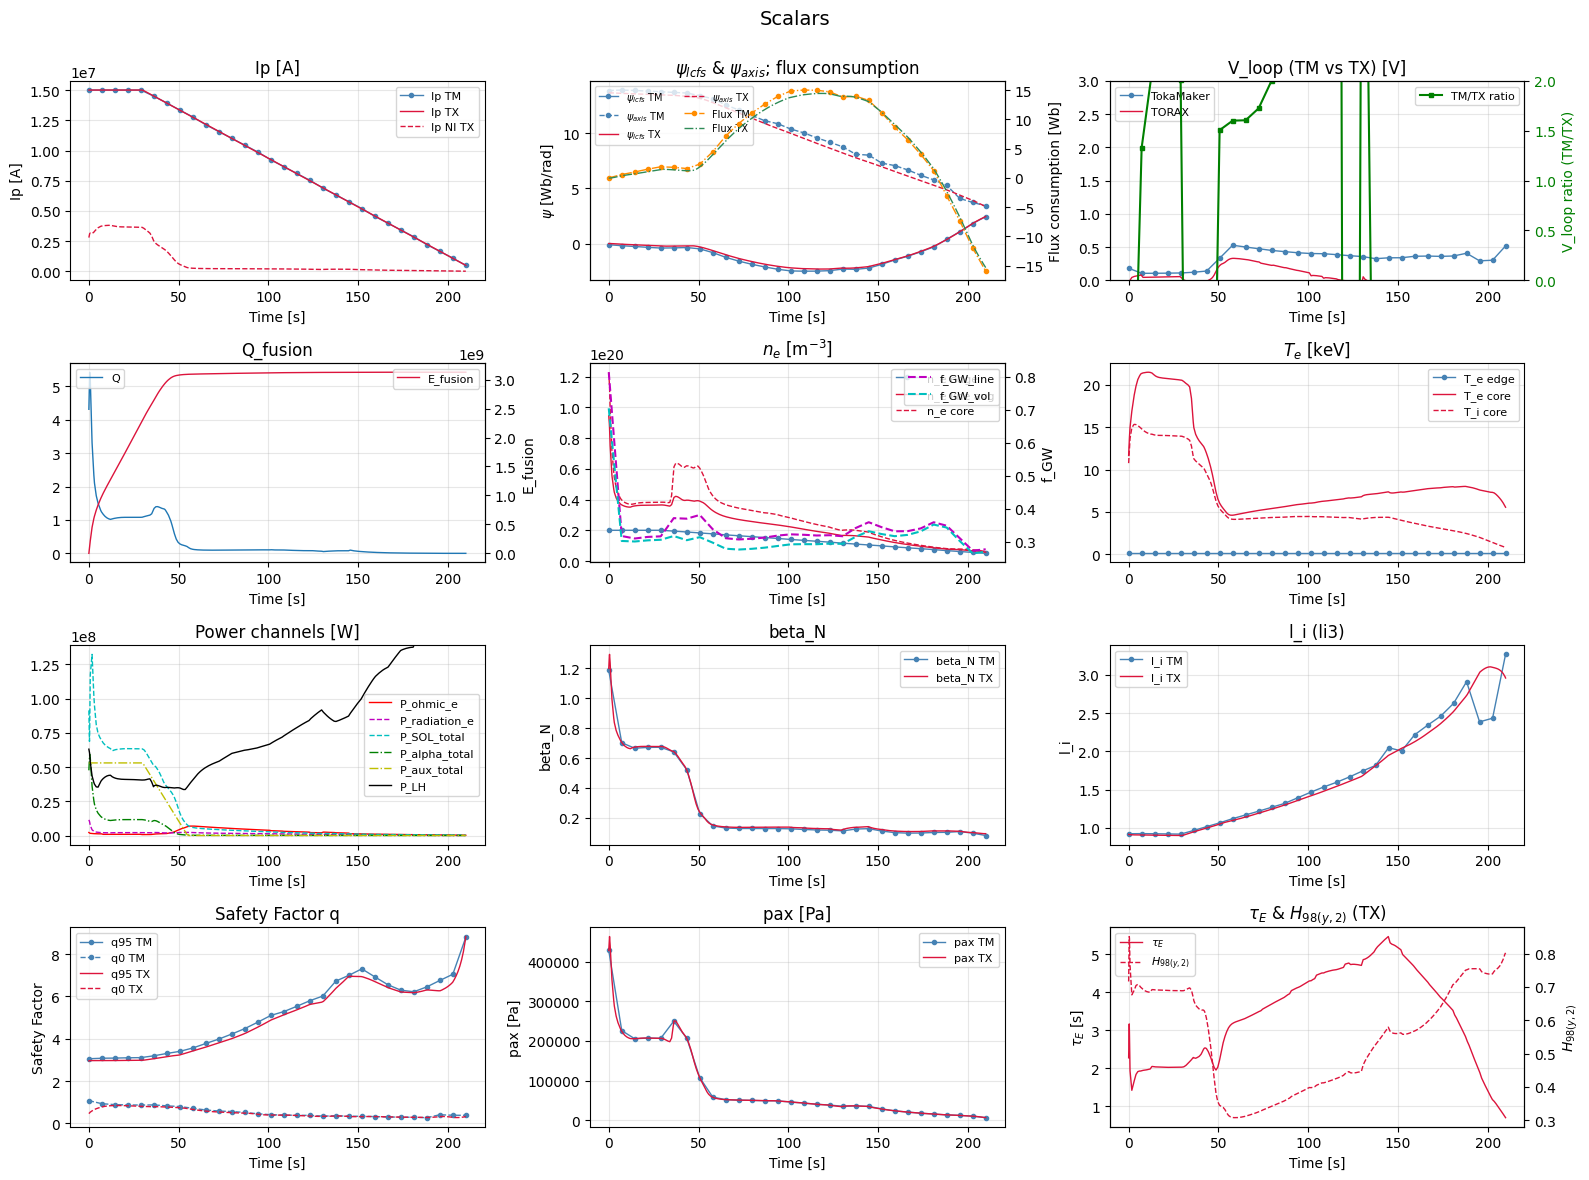

In [ ]:
tt.plot_scalars()


In [ ]:
_ = tt.summary()


  TokTox Physics Summary
  Q_max                           5.424
  Q_max_time                      0.4444
  Q_flattop_avg                   1.566
  E_fusion_total_MJ               3128
  beta_N_max                      1.293
  H98_max                         0.851
  H98_flattop_avg                 0.6995
  T_e_core_max_keV                21.5
  T_i_core_max_keV                15.34
  n_e_line_avg_max                9.448e+19
  f_GW_max                        0.8137
  q95_min                         3.054
  q0_min                          0.2699
  flux_consumed_Wb                -15.93
  P_fusion_max_MW                 297.1
  P_ohmic_max_MW                  6.886
  l_i_flattop_avg                 0.9278
  vloop_tx_flattop_avg_V          0.02728



In [ ]:
tt.make_movie(notebook_mode=True, speed_factor=10)

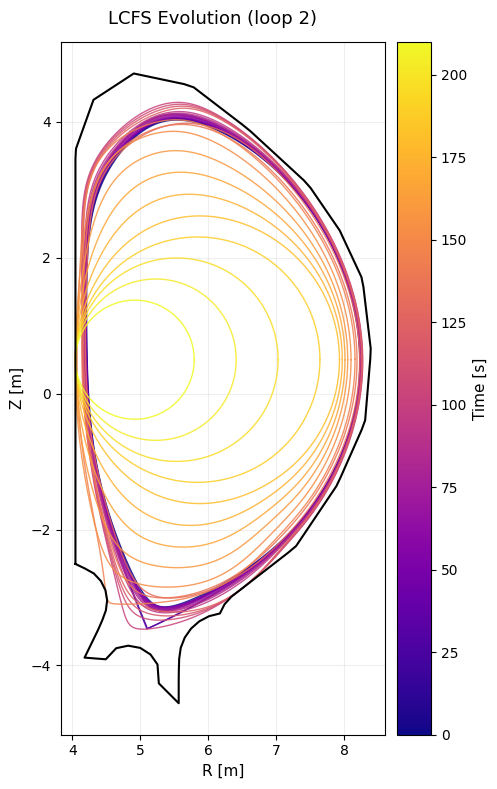

In [ ]:
tt.plot_lcfs_evolution(one_plot=True)


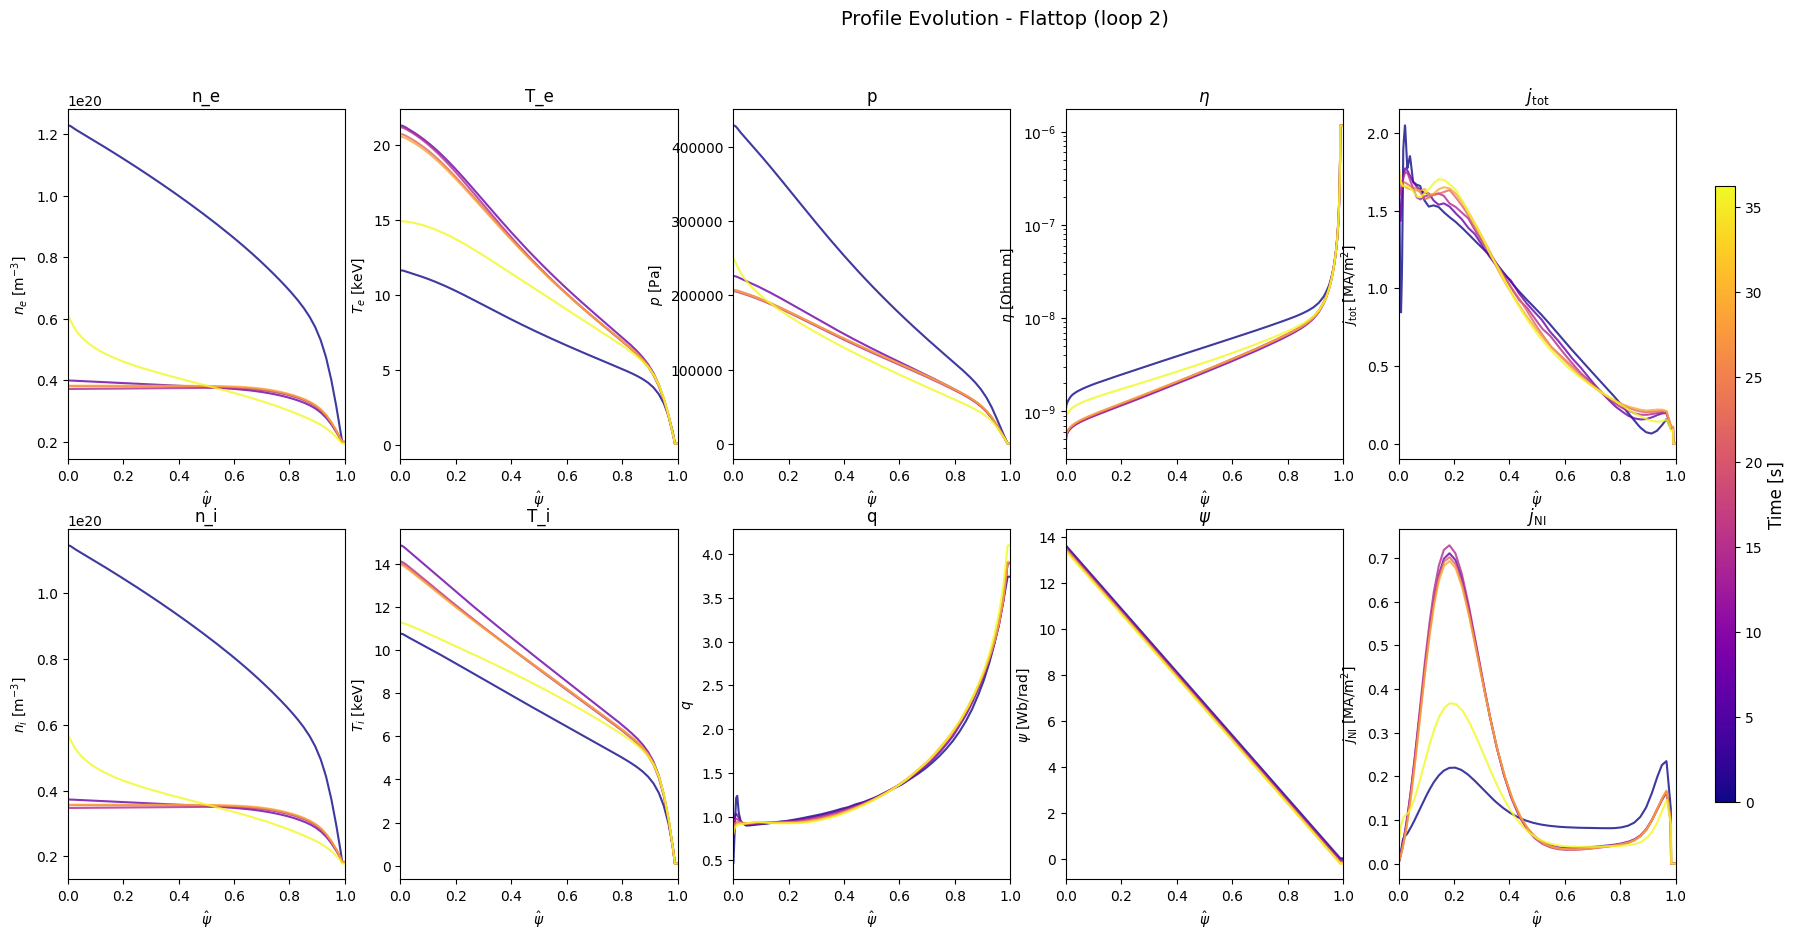

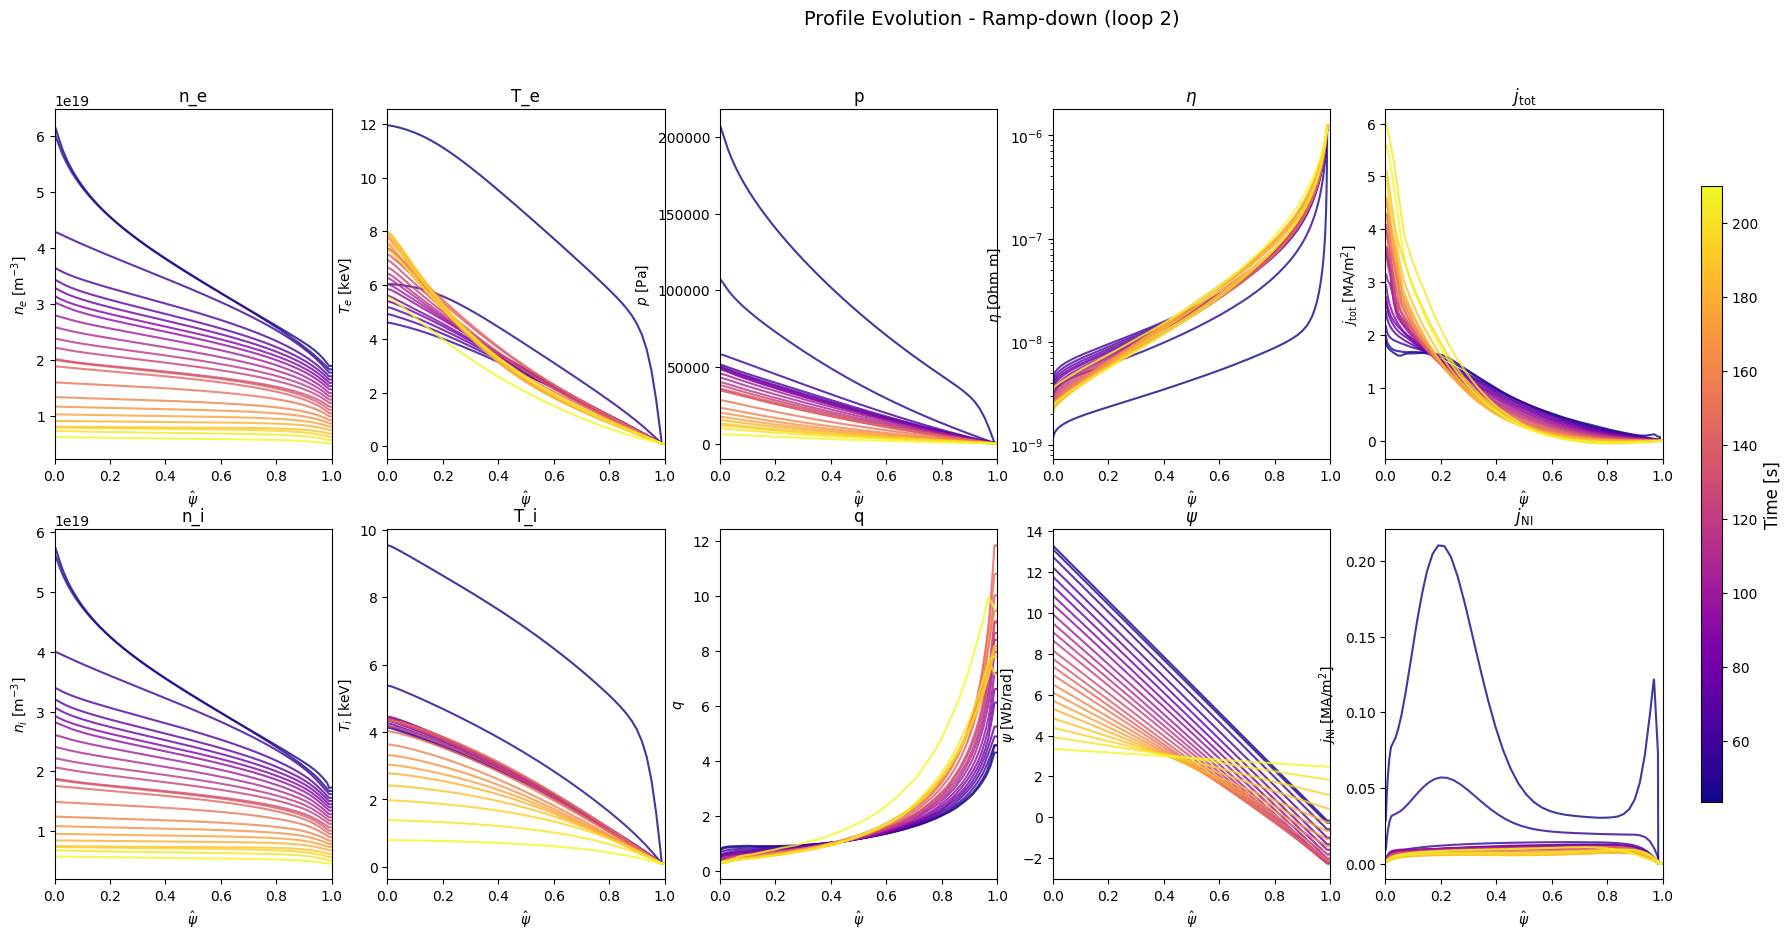

In [ ]:
tt.plot_profile_evolution()


In [ ]:
tt.plot_profiles()


ipywidgets not installed. Install with: pip install ipywidgets


In [ ]:
# print(f'n_e_x = np.{repr(tt._state["n_e"][9]["x"])}')
# print(f'n_e_y = np.{repr(tt._state["n_e"][9]["y"])}')
# print(f'T_e_y = np.{repr(tt._state["T_e"][9]["y"])}')